In [1]:
import os
import sys
import torch
# import logging
import torch.nn as nn
# import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
# from torch.autograd import Variable
# import torchvision.models as models

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy.special import gamma, gammaln

import copy
import datetime
import yaml

import importlib

import tqdm

In [2]:
dirP_str = os.path.join(os.environ['HOME'], 
                    'Python',
                    'aerosol-scattering',
                    'library')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)
    
import evid_nn

In [3]:
is_cuda = torch.cuda.is_available()
device = torch.device(torch.cuda.current_device()) if is_cuda else torch.device("cpu")

if is_cuda:
    torch.backends.cudnn.benchmark = True

print(f'Preparing to use device {device}')

Preparing to use device cuda:0


In [4]:
def transpose_and_flatten_data_array(da: xr.DataArray,flattened_dim_name:str = None) -> xr.DataArray:
    """
    Transposes an xarray DataArray so the first dimension is 'data_index'
    and all other dimensions are flattened into a single second dimension
    named 'flattened_dims'.

    Args:
        da (xr.DataArray): The input DataArray.

    Returns:
        xr.DataArray: The reshaped DataArray with dimensions ('data_index', 'flattened_dims').
                      The 'flattened_dims' dimension will have a MultiIndex if multiple
                      dimensions were stacked, preserving original coordinate information.
    """

    # --- Handle Scalar DataArray ---
    # If the DataArray is a scalar (no dimensions), expand it to a (1,1) array
    # with the desired dimension names.
    if not da.dims:
        return da.expand_dims({'data_index': 1, 'flattened_dims': 1})

    # --- Prepare Dimensions ---
    original_dims = list(da.dims)
    data_index_dim_name = 'data_index'
    if flattened_dim_name is None:
        flattened_dim_name = 'input_vars'

    # Step 1: Ensure 'data_index' is a dimension and is the first dimension.
    if data_index_dim_name not in original_dims:
        # If 'data_index' is not present, assume the current first dimension
        # should be renamed to 'data_index'.
        first_dim_original_name = original_dims[0]
        da = da.rename({first_dim_original_name: data_index_dim_name})
        # Update the list of original_dims to reflect the rename
        original_dims = list(da.dims)
    
    # Now, 'data_index' is guaranteed to be a dimension in `da`.
    # Ensure 'data_index' is the very first dimension.
    if da.dims[0] != data_index_dim_name:
        # Use .transpose() to move 'data_index' to the first position,
        # keeping the relative order of other dimensions.
        da = da.transpose(data_index_dim_name, *[d for d in da.dims if d != data_index_dim_name])

    # --- Flatten Other Dimensions ---
    # Identify all dimensions that are NOT 'data_index'. These will be flattened.
    dims_to_flatten = [d for d in da.dims if d != data_index_dim_name]

    if not dims_to_flatten:
        # If there are no other dimensions (e.g., the original array was already
        # just ('data_index',)), we need to add a 'flattened_dims' dimension
        # of size 1 to achieve the target 2D structure.
        # We use axis=1 to add it as the second dimension.
        return da.expand_dims(flattened_dim_name, axis=1)

    # Use .stack() to combine the identified dimensions into a single new dimension.
    # xarray's .stack() method automatically creates a MultiIndex for the new dimension,
    # which is excellent for preserving the original coordinate information.
    # The new stacked dimension will be added as the last dimension by default.
    # Since 'data_index' was already moved to the first position, the final order
    # will be (data_index, flattened_dims), which is the desired outcome.
    stacked_da = da.stack({flattened_dim_name: dims_to_flatten})

    return stacked_da

In [5]:
def batched_interpolation_with_batched_x(
    a_tnsr: torch.Tensor,
    X_old: torch.Tensor,
    x_new: torch.Tensor
) -> torch.Tensor:
    """
    Interpolates a single 1D tensor (a_tnsr) onto a fixed set of new x-coordinates (x_new),
    using a batch of different original x-coordinate definitions (X_old).

    Args:
        a_tnsr (torch.Tensor): The 1D tensor of y-values to be interpolated. Shape (N,).
        X_old (torch.Tensor): The 2D tensor of original x-coordinates. Shape (B, N).
                              Each row X_old[b, :] defines the x-axis for a_tnsr
                              for that batch item.
        x_new (torch.Tensor): The 1D tensor of new x-coordinates (target points)
                              to interpolate onto. Shape (N_new,).

    Returns:
        torch.Tensor: The interpolated tensor of shape (B, N_new).
    """
    B, N = X_old.shape
    N_new = x_new.shape[0]

    # Ensure all tensors are on the same device
    a_tnsr = a_tnsr.to(X_old.device)
    x_new = x_new.to(X_old.device)

    # Step 1: Find the indices of the two bounding points in X_old for each x_new point.
    # torch.searchsorted needs a sorted_sequence (X_old) and an input (x_new).
    # X_old is (B, N), x_new is (N_new,).
    # searchsorted will broadcast x_new to (B, N_new) and perform the search for each batch.
    # 'right=False' means it finds the index of the first element >= value,
    # so it gives us the index of the right bounding point.
    # FIX: Expand x_new to match the batch dimension of X_old for searchsorted.
    indices = torch.searchsorted(X_old, x_new.unsqueeze(0).expand(B, -1), right=False)
    # Resulting 'indices' shape: (B, N_new)

    # Step 2: Clamp indices to handle extrapolation and boundary conditions.
    # idx_left will be the index of the point to the left of x_new.
    # idx_right will be the index of the point to the right of x_new.
    # Clamping ensures indices are within [0, N-1] for valid lookups.
    idx_left = torch.clamp(indices - 1, 0, N - 1)
    idx_right = torch.clamp(indices, 0, N - 1)

    # For points exactly at x_old[i], searchsorted returns i.
    # So idx_left = i-1, idx_right = i.
    # For points < x_old[0], indices = 0, so idx_left = 0, idx_right = 0.
    # For points >= x_old[N-1], indices = N (if N_new is large enough),
    # so idx_left = N-1, idx_right = N-1.

    # Step 3: Get the x-coordinates of the bounding points from X_old.
    # Use torch.gather to select elements from X_old using the computed indices.
    x_left = torch.gather(X_old, 1, idx_left)   # Shape (B, N_new)
    x_right = torch.gather(X_old, 1, idx_right) # Shape (B, N_new)

    # Step 4: Get the corresponding y-values from a_tnsr.
    # a_tnsr is 1D (N,), but idx_left/idx_right are 2D (B, N_new).
    # PyTorch's advanced indexing handles this by broadcasting a_tnsr across the batch.
    y_left = a_tnsr[idx_left]   # Shape (B, N_new)
    y_right = a_tnsr[idx_right] # Shape (B, N_new)

    # Step 5: Calculate the interpolation factor (alpha).
    # Handle potential division by zero if x_left == x_right (e.g., N=1 or clamped points).
    # In such cases, alpha should effectively be 0 or 1, picking one of the y-values.
    denominator = (x_right - x_left)
    alpha = torch.zeros_like(denominator) # Initialize alpha to zeros
    # Only calculate alpha where denominator is not zero
    non_zero_denom_mask = (denominator != 0)
    alpha[non_zero_denom_mask] = (x_new.unsqueeze(0) - x_left)[non_zero_denom_mask] / denominator[non_zero_denom_mask]

    # Step 6: Perform the linear interpolation.
    # This formula naturally handles both interpolation (alpha between 0 and 1)
    # and extrapolation (alpha outside 0-1 range).
    A_interpolated = y_left * (1 - alpha) + y_right * alpha

    return A_interpolated

In [6]:
# # --- Example Usage ---

# # 1. Define the 1D tensor of y-values (N points)
# original_points_N = 10
# a_tnsr = torch.randn(original_points_N)
# # Make it slightly smoother for better visualization
# a_tnsr = torch.sin(torch.linspace(0, 2 * torch.pi, original_points_N)) + 0.5 * torch.randn(original_points_N)
# print(f"Original a_tnsr shape: {a_tnsr.shape}")
# print(f"Original a_tnsr values:\n{a_tnsr.numpy()}")

# # 2. Define a batch of original x-coordinates (B, N)
# batch_size = 3
# # For demonstration, let's create X_old as slightly shifted/scaled versions of arange(N)
# # This simulates different original x-axes for each batch item.
# X_old = torch.zeros(batch_size, original_points_N)
# for i in range(batch_size):
#     # Each batch item has its own x-axis, slightly shifted and scaled
#     X_old[i, :] = torch.linspace(i * 0.5, (original_points_N - 1) + i * 0.5, original_points_N) + torch.randn(original_points_N) * 0.1
#     # Ensure X_old is sorted for searchsorted
#     X_old[i, :] = torch.sort(X_old[i, :])[0]
# print(f"\nOriginal X_old shape: {X_old.shape}")
# print(f"First X_old batch item:\n{X_old[0].numpy()}")
# print(f"Second X_old batch item:\n{X_old[1].numpy()}")


# # 3. Define the fixed set of new x-coordinates (N_new)
# new_points_N_new = 25
# # Let's choose a fixed new x-axis that covers a common range
# x_new = torch.linspace(0.0, original_points_N + 0.0, new_points_N_new)
# print(f"\nTarget x_new shape: {x_new.shape}")
# print(f"Target x_new points:\n{x_new.numpy()}")

# # Determine device (GPU if available, else CPU)
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# print(f"Using device: {device}")
# a_tnsr = a_tnsr.to(device)
# X_old = X_old.to(device)
# x_new = x_new.to(device)

# # Perform interpolation
# interpolated_A = batched_interpolation_with_batched_x(a_tnsr, X_old, x_new)
# print(f"\nInterpolated A shape: {interpolated_A.shape}")

# # --- Verification (Optional, using a for loop for comparison) ---
# print("\n--- Verification (using a for loop for comparison) ---")
# from scipy.interpolate import interp1d

# A_interpolated_scipy = torch.zeros_like(interpolated_A, device=device)

# for i in range(B):
#     f_interp = interp1d(X_old[i].cpu().numpy(), a_tnsr.cpu().numpy(), kind='linear',
#                         bounds_error=False, fill_value='extrapolate')
#     A_interpolated_scipy[i] = torch.from_numpy(f_interp(x_new.cpu().numpy())).to(device)

# # Check if the results are close (allowing for float precision differences)
# assert torch.allclose(interpolated_A, A_interpolated_scipy, atol=1e-6)
# print("Verification successful: PyTorch vectorized interpolation matches SciPy's interp1d.")

# # --- Plotting one batch item for visualization ---
# try:
#     import matplotlib.pyplot as plt
#     plt.figure(figsize=(12, 8))
#     for i in range(B):
#         plt.plot(X_old[i].cpu().numpy(), a_tnsr.cpu().numpy(), 'o', alpha=0.5,
#                  label=f'Original Points (Batch {i})')
#         plt.plot(x_new.cpu().numpy(), interpolated_A[i].cpu().numpy(), 'x-',
#                  label=f'Interpolated Points (Batch {i})')

#     plt.title('Batched Interpolation with Varying Original X-Axes')
#     plt.xlabel('X-coordinate')
#     plt.ylabel('Y-value')
#     plt.legend()
#     plt.grid(True)
#     plt.show()
# except ImportError:
#     print("\nMatplotlib not installed. Skipping plot visualization.")

In [7]:

def batched_linear_interpolation(
    A_tnsr: torch.Tensor,
    n_new: torch.Tensor,
    x_old: torch.Tensor = None
) -> torch.Tensor:
    """
    Performs 1D linear interpolation on each row of a batched tensor A_tnsr.

    Args:
        A_tnsr (torch.Tensor): Input tensor of shape (B, N) where B is batch size
                               and N is the number of points in each sequence.
        n_new (torch.Tensor): 1D tensor of new x-coordinates (target points)
                              to interpolate to. Shape (N_new,).
        x_old (torch.Tensor, optional): 1D tensor of original x-coordinates.
                                       Shape (N,). If None, assumes x_old is
                                       torch.arange(N) (i.e., 0, 1, ..., N-1).
                                       Defaults to None.

    Returns:
        torch.Tensor: Interpolated tensor of shape (B, N_new).
    """
    B, N = A_tnsr.shape
    N_new = n_new.shape[0]

    # Ensure tensors are on the same device
    n_new = n_new.to(A_tnsr.device)

    # Define original x-coordinates if not provided
    if x_old is None:
        x_old = torch.arange(N, device=A_tnsr.device, dtype=A_tnsr.dtype)
    else:
        x_old = x_old.to(A_tnsr.device)
        if x_old.shape[0] != N:
            raise ValueError(f"x_old must have {N} points, but got {x_old.shape[0]}.")

    # Find the indices of the two bounding points in x_old for each n_new point.
    # torch.searchsorted returns indices such that x_old[indices-1] < n_new <= x_old[indices].
    # Using right=False means it finds the index of the first element >= value,
    # so it gives us the index of the right bounding point.
    # We want the left bounding point, so we adjust.
    indices = torch.searchsorted(x_old, n_new, right=False)

    # Clamp indices to handle extrapolation:
    # For n_new < x_old[0], indices will be 0.
    # For n_new >= x_old[N-1], indices will be N-1 (or N if N_new is very large).
    # We need to ensure idx_left is at least 0 and idx_right is at most N-1.
    idx_left = torch.clamp(indices - 1, 0, N - 2) # Ensure idx_left is valid for x_old[idx_left]
    idx_right = torch.clamp(indices, 1, N - 1)   # Ensure idx_right is valid for x_old[idx_right]

    # Handle cases where n_new exactly matches an x_old point or is outside range
    # If n_new is exactly x_old[i], then idx_left will be i-1 and idx_right will be i.
    # If n_new is < x_old[0], then idx_left=0, idx_right=0.
    # If n_new is >= x_old[N-1], then idx_left=N-1, idx_right=N-1.
    # The clamping ensures we always have valid indices for y_left and y_right.

    # Get the x-coordinates of the bounding points
    x_left = x_old[idx_left]
    x_right = x_old[idx_right]

    # Get the corresponding y-values from A_tnsr.
    # A_tnsr[:, idx_left] will broadcast idx_left across the batch dimension B.
    y_left = A_tnsr[:, idx_left]   # Shape (B, N_new)
    y_right = A_tnsr[:, idx_right] # Shape (B, N_new)

    # Calculate the interpolation factor (alpha)
    # Handle division by zero for cases where x_left == x_right (e.g., N=1 or extrapolation at exact points)
    # In such cases, alpha can be 0 or 1, which correctly picks y_left or y_right.
    # If x_left == x_right, alpha will be 0/0, which results in NaN. Replace NaN with 0 or 1.
    # For robustness, handle the denominator. If x_right == x_left, alpha should be 0.
    denominator = (x_right - x_left)
    alpha = torch.zeros_like(denominator) # Initialize alpha to zeros
    # Only calculate alpha where denominator is not zero
    non_zero_denom_mask = (denominator != 0)
    alpha[non_zero_denom_mask] = (n_new - x_left)[non_zero_denom_mask] / denominator[non_zero_denom_mask]

    # For extrapolation points:
    # If n_new < x_old[0], alpha will be negative.
    # If n_new > x_old[N-1], alpha will be > 1.
    # Linear interpolation formula naturally handles this as extrapolation.

    # Perform the linear interpolation
    A_interpolated = y_left * (1 - alpha) + y_right * alpha

    return A_interpolated

# Multi Model Analysis

In [8]:
model_str_lst = [
    # "20250802T072914",  # 3 wavelength
    "20250809T063604",  # 3 wavelength retrain to align with other training approach
    "20250804T203116",  # 355 and 532
    "20250804T064411",  # 355 and 1064
    "20250803T203355",  # 532 and 1064
    "20250805T055249",  # 355
    "20250805T144451",  # 532
    "20250806T060633",  # 1064

    # backscatter only
    "20250802T201718",  # 3 wavelength
]

In [9]:
# load the config of the first model to set the 
# conf_reload, model_reload = evid_nn.load_poly_nn_model(model_str_lst[0],name_str='hyper_best',device=device)

In [10]:
percentile_lst = [0.01, 0.05, 0.1, 0.2, 0.8, 0.9, 0.95, 0.99]
hist_width = 0.01
example_count = 10

# idx_arr = np.array([18334])
# idx_arr = np.array([60308, 11462, 44852,  6123, 41998, 50674, 87012, 87725, 87707, 17718])
idx_arr = np.array([60308, 11462, 44852,  6123, 41998, 50674, 87012, 87725, 87707, 18334, 44305, 44535, 49700, 55717, 55721, 55744,
        55875, 55960, 56042, 56201, 56414, 56527, 56740, 56798, 56810,
        56822, 56823, 62837, 65213, 53289])

In [11]:
conf_lst = []

r_centroid_arr_lst = []
n_centroid_arr_lst = []
r2_centroid_arr_lst = []
n2_centroid_arr_lst = []
r_act_arr_lst = []
n_act_arr_lst = []
p_model_arr_lst = []

x_rescale_lst = []
y_rescale_lst = []

label_param_lst_lst = []
label_wl_lst_lst = []

r_interval_arr_lst = []
n_interval_arr_lst = []

r_sim_hist_lst_lst = []
n_sim_hist_lst_lst = []

sim_hist_in_data_lst_lst = []

f_pdf_arr_lst = []
f_pdf_ens_arr_lst = []


for m_idx, model_str in enumerate(model_str_lst):
    print(f"loading model {m_idx+1} of {len(model_str_lst)}")
    conf_reload, model_reload = evid_nn.load_poly_nn_model(model_str,name_str='hyper_best',device=device)
    x_scaler = evid_nn.rescale(0,1)
    x_scaler.set_config(**conf_reload['save_model']['x_scaler'])
    y_scaler = evid_nn.rescale(0,1)
    y_scaler.set_config(**conf_reload['save_model']['y_scaler'])

    x_rescale_lst.append(x_scaler)
    y_rescale_lst.append(y_scaler)

    conf_lst.append(conf_reload)
    conf = conf_reload
    dtype = model_reload.dtype

    if m_idx == 0:
        intrp_tnsr = torch.tensor(percentile_lst,dtype=dtype,device=device)

    
    label_param_lst = []
    label_wl_lst = []
    
    if 'extinction_coefficient' in conf_reload['data']['wavelength_inputs']:
        label_param_lst.append(r"$\alpha$")
        wl_key='extinction_coefficient'
    if 'backscatter_coefficient' in conf_reload['data']['wavelength_inputs']:
        label_param_lst.append(r"$\beta$")
        wl_key='backscatter_coefficient'

    for wl in conf_reload['data']['wavelength_inputs'][wl_key]['wavelength_lst']:
        label_wl_lst.append(str(int(wl*1e9)))

    label_param_lst_lst.append(label_param_lst)
    label_wl_lst_lst.append(label_wl_lst)


    ### Load Data ###
    # this is repeated because rescaling could theoretically be different between models
    
    override_validation = False  # forces the validation data to be split from training

    rank = 0
    trial = False
    
    
    # device = torch.device(f"cuda:{rank % torch.cuda.device_count()}") if torch.cuda.is_available() else torch.device("cpu")
    # torch.cuda.set_device(rank % torch.cuda.device_count())
    # if conf['model']['dtype'] == 'float32':
    #     dtype = torch.float32
    # elif conf['model']['dtype'] == 'float64':
    #     dtype = torch.float64
    # else:
    #     dtype = torch.float
    
    # Config settings
    # seed = 1000 if "seed" not in conf else conf["seed"]
    # seed_everything(seed)
    
    
    ds = xr.open_dataset(os.path.join(conf['data']['data_path'],conf['data']['data_file']))
    
    train_batch_size = conf['data']['batch_size']
    valid_batch_size = conf['data']['batch_size']
    test_batch_size = conf['data']['batch_size']
    
    train_idx = int(np.round(ds.sizes['data_index']*conf['data']['train_fraction']))
    valid_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['valid_fraction']))
    test_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['test_fraction']))
    
    
    input_lst = []
    input_str_lst = []
    for var in conf['data']['wavelength_inputs']:
        for wl in conf['data']['wavelength_inputs'][var]['wavelength_lst']:
            input_lst.append(transpose_and_flatten_data_array(ds[var].sel(wavelength=wl)))
            input_str_lst.append(var+f"_{int(wl*1e9)}")
    for var in conf['data']['input_cols']:
        input_lst.append(transpose_and_flatten_data_array(ds[var],flattened_dim_name='input_vars'))
        input_str_lst.append(var)
    
    train_input_arr = xr.concat(input_lst,pd.Index(input_str_lst,name='input_vars'))
    
    output_lst = []
    output_str_lst = []
    for var in conf['data']['output_cols']:
        output_lst.append(transpose_and_flatten_data_array(ds[var],flattened_dim_name='label_vars'))
        output_str_lst.append(var)
    
    train_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))
    
    
    if not override_validation:
        valid_ds = xr.open_dataset(os.path.join(conf['data']['valid_data_path'],conf['data']['valid_data_file']))
        input_lst = []
        # input_str_lst = []
        for var in conf['data']['wavelength_inputs']:
            for wl in conf['data']['wavelength_inputs'][var]['wavelength_lst']:
                input_lst.append(transpose_and_flatten_data_array(valid_ds[var].sel(wavelength=wl)))
        for var in conf['data']['input_cols']:
            input_lst.append(transpose_and_flatten_data_array(valid_ds[var],flattened_dim_name='input_vars'))
        
        valid_input_arr = xr.concat(input_lst,pd.Index(input_str_lst,name='input_vars'))
        
        output_lst = []
        for var in conf['data']['output_cols']:
            output_lst.append(transpose_and_flatten_data_array(valid_ds[var],flattened_dim_name='label_vars'))
            # output_str_lst.append(var)
        
        valid_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))
        
        x_train = x_scaler.scale(np.log(train_input_arr.values))
        x_valid = x_scaler.scale(np.log(valid_input_arr.values))
        
        y_train = y_scaler.scale(np.log(train_label_arr.values))
        y_valid = y_scaler.scale(np.log(valid_label_arr.values))
    else:
        print("validation dataset encountered an error:")
        print("override_validation=True, so validation is split from training data")
        # print(str(E))
        x_train = x_scaler.scale(np.log(train_input_arr.values[:train_idx,:]))
        x_valid = x_scaler.scale(np.log(train_input_arr.values[train_idx:valid_idx,:]))
        
        y_train = y_scaler.scale(np.log(train_label_arr.values[:train_idx,:]))
        y_valid = y_scaler.scale(np.log(train_label_arr.values[train_idx:valid_idx,:]))
    
    
    cond_args = conf['data']['cond_args']
    
    train_dataset = evid_nn.EvidDataset(x_train,y_train,
                                dtype=dtype,device=device,
                                **cond_args)
    valid_dataset = evid_nn.EvidDataset(x_valid,y_valid,
                                dtype=dtype,device=device,
                                **cond_args)
    # test_dataset = evid_nn.EvidDataset(x_test,y_test,
    #                             dtype=dtype,device=device,
    #                             **cond_args)
    
    train_dataloader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=valid_batch_size, shuffle=True)
    
    test_ds = xr.open_dataset(os.path.join(conf['data']['test_data_path'],conf['data']['test_data_file']))
    input_lst = []
    # input_str_lst = []
    for var in conf['data']['wavelength_inputs']:
        for wl in conf['data']['wavelength_inputs'][var]['wavelength_lst']:
            input_lst.append(transpose_and_flatten_data_array(test_ds[var].sel(wavelength=wl)))
    for var in conf['data']['input_cols']:
        input_lst.append(transpose_and_flatten_data_array(test_ds[var],flattened_dim_name='input_vars'))
    
    test_input_arr = xr.concat(input_lst,pd.Index(input_str_lst,name='input_vars'))
    
    output_lst = []
    for var in conf['data']['output_cols']:
        output_lst.append(transpose_and_flatten_data_array(test_ds[var],flattened_dim_name='label_vars'))
    
    test_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))
    
    x_test = x_scaler.scale(np.log(test_input_arr.values))
    
    y_test = y_scaler.scale(np.log(test_label_arr.values))
    
    test_dataset = evid_nn.EvidDataset(x_test,y_test,
                                dtype=dtype,device=device,
                                **cond_args)
    
    test_dataloader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

    ### End Data Loader ###

    # in_data = x_train
    # out_label = y_train
    
    # in_data = x_valid
    # out_label = y_valid

    ### Perform example analysis ###
    # actual sample data
    in_data = x_test
    out_label = y_test

    # data for histogram analysis
    hist_in_data = np.concatenate([x_train,x_valid,x_test],axis=0)
    hist_out_label = np.concatenate([y_train,y_valid,y_test],axis=0)

    if m_idx == 0:
        # idx_arr = (np.random.rand(example_count)*in_data.shape[0]).astype(int)  # get random input
        r_act = out_label[:,1][idx_arr]
        n_act = out_label[:,0][idx_arr]
        
    sim_idx_lst = []
    r_sim_hist_lst = []
    n_sim_hist_lst = []
    sim_hist_in_data_lst = []
    for sidx in range(idx_arr.size):
        idx = idx_arr[sidx]
        sim_idx = np.where(np.prod(np.abs(hist_in_data - in_data[idx,:].reshape(1,-1)) < hist_width,axis=1))
        sim_idx_lst.append(sim_idx)

        sim_hist_in_data_lst.append(hist_in_data[sim_idx])

        r_sim_hist = hist_out_label[:,1][sim_idx]
        n_sim_hist = hist_out_label[:,0][sim_idx]

        r_sim_hist_lst.append(r_sim_hist)
        n_sim_hist_lst.append(n_sim_hist)

    r_sim_hist_lst_lst.append(r_sim_hist_lst)
    n_sim_hist_lst_lst.append(n_sim_hist_lst)
    sim_hist_in_data_lst_lst.append(sim_hist_in_data_lst)

    # pdf_ax = np.exp(y_scaler.unscale(np.stack([x_plt,x_plt],axis=1)))
    # hist_ax = np.exp(y_scaler.unscale(np.stack([h_part[1],h_part[2]],axis=1)))
    # act_ax = np.exp(y_scaler.unscale(np.stack([np.array([n_act]),np.array([r_act])],axis=1))).squeeze()

    # pdf_ax_lst.append(pdf_ax)
    # hist_ax_lst.append(hist_ax)
    # act_ax_lst.append(act_ax)
        

    f_pdf_lst = []
    f_pdf_ens_lst = []
    with torch.no_grad():
        for sidx, sim_idx in enumerate(sim_idx_lst):
            idx = idx_arr[sidx]
            f_pdf_tnsr = model_reload.output_pdf(torch.tensor(in_data[idx:(idx+1),:],dtype=dtype,device=device))
            f_pdf = f_pdf_tnsr.detach().cpu().numpy()
            x_plt = model_reload.x_int.detach().cpu().numpy()
            
            ensemble_size = 100
            ensemble_width = hist_width # (observation uncertainty)
            loop_length = 4
            f_pdf_ens = np.zeros((f_pdf.shape[1],f_pdf.shape[2]))
            for ens_group_idx in range(loop_length):
                f_pdf_ens_tnsr = model_reload.output_pdf(torch.tensor(in_data[idx:(idx+1),:]+(np.random.rand(ensemble_size,in_data.shape[1])*2-1)*ensemble_width,dtype=dtype,device=device))
                f_pdf_ens += np.sum(f_pdf_ens_tnsr.detach().cpu().numpy(),axis=0)
                # print(ens_group_idx)
            
            f_pdf_ens = f_pdf_ens/(loop_length*ensemble_size)

            f_pdf_lst.append(f_pdf)
            f_pdf_ens_lst.append(f_pdf_ens)

    f_pdf_arr_lst.append(np.concatenate(f_pdf_lst,axis=0))
    f_pdf_ens_arr_lst.append(np.stack(f_pdf_ens_lst,axis=0))

    
        

    ### perform aggregate analysis ###

    batch_size = 256
    ensemble_size = 100
    ensemble_width = 0.01 # (observation uncertainty)
    batch_count = in_data.shape[0]//batch_size
    
    r_centroid_lst = []
    n_centroid_lst = []
    r2_centroid_lst = []
    n2_centroid_lst = []
    r_centroid_ens_lst = []
    n_centroid_ens_lst = []
    r_act_lst = []
    n_act_lst = []
    p_model_lst = []
    r_interval_lst = []
    n_interval_lst = []
    
    with torch.no_grad():
        for batch in tqdm.tqdm(range(batch_count)):
            input_batch = torch.tensor(in_data[batch*batch_size:((batch+1)*batch_size),:], dtype=dtype, device=device)
            
            f_pdf_tnsr = model_reload.output_pdf(input_batch)
            # f_pdf = f_pdf_tnsr.detach().cpu().numpy()
            # x_plt = model_reload.x_int.detach().cpu().numpy()
            # dx2 = (model_reload.dx_int**2).detach().cpu().numpy()
            cdf_r = torch.cumsum(torch.sum(f_pdf_tnsr,dim=1),dim=1)*model_reload.dx_int**2
            cdf_n = torch.cumsum(torch.sum(f_pdf_tnsr,dim=2),dim=1)*model_reload.dx_int**2
            r_interval_lst.append(batched_interpolation_with_batched_x(model_reload.x_int,cdf_r,intrp_tnsr).detach().cpu().numpy())
            n_interval_lst.append(batched_interpolation_with_batched_x(model_reload.x_int,cdf_n,intrp_tnsr,).detach().cpu().numpy())
        
            r_centroid_lst.append(torch.sum(model_reload.x_int.detach().reshape(1,1,-1)*f_pdf_tnsr*model_reload.dx_int**2,dim=(1,2)).detach().cpu().numpy())
            n_centroid_lst.append(torch.sum(model_reload.x_int.detach().reshape(1,-1,1)*f_pdf_tnsr*model_reload.dx_int**2,dim=(1,2)).detach().cpu().numpy())
            r2_centroid_lst.append(torch.sum(model_reload.x_int.detach().reshape(1,1,-1)**2*f_pdf_tnsr*model_reload.dx_int**2,dim=(1,2)).detach().cpu().numpy())
            n2_centroid_lst.append(torch.sum(model_reload.x_int.detach().reshape(1,-1,1)**2*f_pdf_tnsr*model_reload.dx_int**2,dim=(1,2)).detach().cpu().numpy())
        
            r_act_lst.append(out_label[batch*batch_size:((batch+1)*batch_size),1])
            n_act_lst.append(out_label[batch*batch_size:((batch+1)*batch_size),0])
        
            fit_coef = model_reload.net(input_batch)
            p_model = model_reload.fpdf(fit_coef, input_batch)
            p_model_lst.append(p_model.detach().cpu().numpy())
    
    
        r_centroid_arr_lst.append(np.concatenate(r_centroid_lst))
        n_centroid_arr_lst.append(np.concatenate(n_centroid_lst))
        r2_centroid_arr_lst.append(np.concatenate(r2_centroid_lst))
        n2_centroid_arr_lst.append(np.concatenate(n2_centroid_lst))
        r_act_arr_lst.append(np.concatenate(r_act_lst))
        n_act_arr_lst.append(np.concatenate(n_act_lst))
        p_model_arr_lst.append(np.concatenate(p_model_lst))
        r_interval_arr_lst.append(np.concatenate(r_interval_lst,axis=0))
        n_interval_arr_lst.append(np.concatenate(n_interval_lst,axis=0))


loading model 1 of 8
loading model from 
/glade/u/home/mhayman/Python/aerosol-scattering/models


  0%|          | 0/354 [00:00<?, ?it/s]/glade/derecho/scratch/mhayman/tmp/ipykernel_45703/1936244777.py:35: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at ../aten/src/ATen/native/BucketizationUtils.h:32.)
  indices = torch.searchsorted(X_old, x_new.unsqueeze(0).expand(B, -1), right=False)
100%|██████████| 354/354 [01:54<00:00,  3.09it/s]


loading model 2 of 8
loading model from 
/glade/u/home/mhayman/Python/aerosol-scattering/models


100%|██████████| 354/354 [00:52<00:00,  6.80it/s]


loading model 3 of 8
loading model from 
/glade/u/home/mhayman/Python/aerosol-scattering/models


...

100%|██████████| 354/354 [00:58<00:00,  6.05it/s]


loading model 7 of 8
loading model from 
/glade/u/home/mhayman/Python/aerosol-scattering/models


100%|██████████| 354/354 [01:19<00:00,  4.44it/s]


loading model 8 of 8
loading model from 
/glade/u/home/mhayman/Python/aerosol-scattering/models


100%|██████████| 354/354 [00:56<00:00,  6.30it/s]


In [12]:
model_reload.dx_int

tensor(0.0010, device='cuda:0', dtype=torch.float64)

In [13]:
cdf_r.shape

torch.Size([256, 1000])

In [14]:
cdf_r

tensor([[3.9286e-12, 7.8015e-12, 1.1631e-11,  ..., 1.0000e+00, 1.0000e+00,
         1.0000e+00],
        [1.2713e-12, 2.5999e-12, 3.9894e-12,  ..., 1.0000e+00, 1.0000e+00,
         1.0000e+00],
        [5.6793e-13, 1.1254e-12, 1.6745e-12,  ..., 1.0000e+00, 1.0000e+00,
         1.0000e+00],
        ...,
        [1.1592e-08, 2.3087e-08, 3.4482e-08,  ..., 1.0000e+00, 1.0000e+00,
         1.0000e+00],
        [3.5932e-11, 7.0844e-11, 1.0476e-10,  ..., 1.0000e+00, 1.0000e+00,
         1.0000e+00],
        [2.2610e-09, 4.4940e-09, 6.6996e-09,  ..., 1.0000e+00, 1.0000e+00,
         1.0000e+00]], device='cuda:0', dtype=torch.float64)

In [15]:
r_interval_lst[-1][10]

array([0.21134449, 0.24359724, 0.26477085, 0.292543  , 0.38048062,
       0.40361265, 0.42666053, 0.48299363])

In [16]:
# cdf_r = torch.cumsum(torch.sum(f_pdf_tnsr,dim=1),dim=1)
# cdf_n = torch.cumsum(torch.sum(f_pdf_tnsr,dim=2),dim=1)

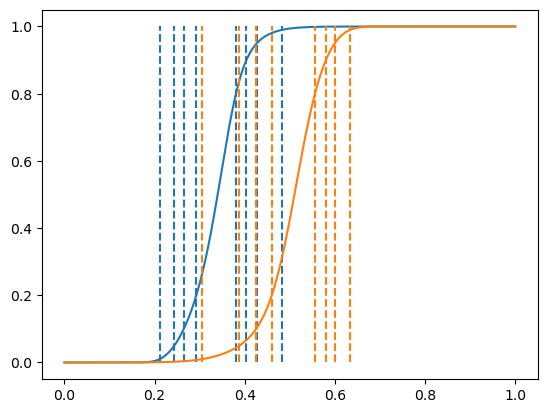

In [17]:
plt.figure()
plt.plot(model_reload.x_int.detach().cpu().numpy(), cdf_r[10,...].detach().cpu().numpy(),color='C0')
for r_interval in r_interval_lst[-1][10]:
    plt.plot([r_interval, r_interval], [0,1],linestyle='--',color='C0')
plt.plot(model_reload.x_int.detach().cpu().numpy(), cdf_n[10,...].detach().cpu().numpy(),color='C1')
for n_interval in n_interval_lst[-1][10]:
    plt.plot([n_interval, n_interval], [0,1],linestyle='--',color='C1')

In [18]:
f_pdf_tnsr.shape

torch.Size([256, 1000, 1000])

In [19]:
", ".join(label_wl_lst_lst[m_idx])

'1064, 532, 355'

In [20]:
# r_interval_arr = np.concatenate(r_interval_arr_lst,axis=0)
# n_interval_arr = np.concatenate(n_interval_arr_lst,axis=0)

In [21]:
# r_interval_arr.shape

In [22]:
percentile_data_ln_lst_lst = []
percentile_model_sets = []
for m_idx, y_scaler in enumerate(y_rescale_lst):
    percentile_data_ln_lst = []
    percentile_sets = []
    for i_per in range(r_interval_arr_lst[m_idx].shape[1]//2):
        print(f"{percentile_lst[i_per]} to {percentile_lst[-1-i_per]}")
        percentile_data_ln_1 = y_scaler.unscale(np.stack([n_interval_arr_lst[m_idx][:,i_per],r_interval_arr_lst[m_idx][:,i_per]],axis=1))
        percentile_data_ln_2 = y_scaler.unscale(np.stack([n_interval_arr_lst[m_idx][:,-1-i_per],r_interval_arr_lst[m_idx][:,-1-i_per]],axis=1))
        percentile_data_ln_lst.append([percentile_data_ln_1,percentile_data_ln_2])
        percentile_sets.append([percentile_lst[i_per],percentile_lst[-1-i_per]])

    percentile_data_ln_lst_lst.append(percentile_data_ln_lst)
    percentile_model_sets.append(percentile_sets)

0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8


In [23]:
r_interval_arr_lst[m_idx][:,1]

array([0.23506779, 0.21255686, 0.22176118, ..., 0.24868535, 0.23977049,
       0.25750461])

In [24]:
n_interval_arr_lst[m_idx][:,4]

array([0.61635591, 0.54634448, 0.55969675, ..., 0.54564341, 0.50198235,
       0.52133451])

In [25]:
percentile_data_ln_1.shape

(90624, 2)

In [26]:
act_data_ln_lst = []
centroid_data_ln_lst = []
hr_lst = []
hn_lst = []
hr_2d_lst = []
hn_2d_lst = []
hcmb_lst = []
for m_idx, y_scaler in enumerate(y_rescale_lst):
    act_data_ln = y_scaler.unscale(np.stack([n_act_arr_lst[m_idx],r_act_arr_lst[m_idx]],axis=1))
    centroid_data_ln = y_scaler.unscale(np.stack([n_centroid_arr_lst[m_idx],r_centroid_arr_lst[m_idx]],axis=1))

    act_data_ln_lst.append(act_data_ln)
    centroid_data_ln_lst.append(centroid_data_ln)

    # hcmb = np.histogram2d(np.abs(act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),
    #                 np.abs(act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),
    #                 bins=(np.linspace(0,0.25,100),np.linspace(-0.5,0.5,100)))
    
    hcmb = np.histogram2d((act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),
                    (act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),
                    bins=(np.linspace(-0.5,0.5,100),np.linspace(-1,1,100)))

    hn_2d = np.histogram2d(np.exp(act_data_ln[:,0]),
                    np.exp(centroid_data_ln[:,0]),
                    bins=(np.logspace(0,4,100),np.logspace(0,4,100)))

    hr_2d = np.histogram2d(np.exp(act_data_ln[:,1]),
                    np.exp(centroid_data_ln[:,1]),
                    bins=(np.logspace(-8,-6,100),np.logspace(-8,-6,100)))


    # hr = np.histogram(np.abs(act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(0,1,100))
    hr = np.histogram((act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(-1,1,100))


    # hn = np.histogram(np.abs(act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(0,2,100))
    hn = np.histogram((act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(-2,2,100))

    hr_lst.append(hr)
    hn_lst.append(hn)
    hcmb_lst.append(hcmb)
    hr_2d_lst.append(hr_2d)
    hn_2d_lst.append(hn_2d)


In [27]:
# hist_out_label
hist_act_data_ln = y_rescale_lst[-1].unscale(hist_out_label)
hr_prior = np.histogram((act_data_ln[:,1]-np.mean(hist_act_data_ln[:,1]))*np.log10(np.exp(1)),bins=np.linspace(-1,1,100))

hn_prior = np.histogram((act_data_ln[:,0]-np.mean(hist_act_data_ln[:,0]))*np.log10(np.exp(1)),bins=np.linspace(-2,2,100))

hcmb_prior = np.histogram2d((act_data_ln[:,1]-np.mean(hist_act_data_ln[:,1]))*np.log10(np.exp(1)),
                    (act_data_ln[:,0]-np.mean(hist_act_data_ln[:,0]))*np.log10(np.exp(1)),
                    bins=(np.linspace(-0.5,0.5,100),np.linspace(-1,1,100)))

In [28]:
# total histogram of training/test/validation data
h_part_total = np.histogram2d(hist_out_label[:,1],hist_out_label[:,0],bins=np.linspace(0,1,500))


r_cdf_prior = np.cumsum(np.sum(h_part_total[0],axis=0))/np.sum(h_part_total[0])
n_cdf_prior = np.cumsum(np.sum(h_part_total[0],axis=1))/np.sum(h_part_total[0])

r_tot_interval = np.interp(percentile_lst,r_cdf_prior,0.5*(h_part_total[1][:-1]+h_part_total[1][1:]))
n_tot_interval = np.interp(percentile_lst,n_cdf_prior,0.5*(h_part_total[2][:-1]+h_part_total[2][1:]))

y_scaler = y_rescale_lst[-1]

percentile_prior_ln_lst = []
for i_per in range(r_interval_arr_lst[m_idx].shape[1]//2):
    print(f"{percentile_lst[i_per]} to {percentile_lst[-1-i_per]}")
    percentile_prior_ln_1 = y_scaler.unscale(np.array([[n_tot_interval[i_per]],[r_tot_interval[i_per]]]).T)
    percentile_prior_ln_2 = y_scaler.unscale(np.array([[n_tot_interval[-1-i_per]],[r_tot_interval[-1-i_per]]]).T)
    percentile_prior_ln_lst.append([percentile_prior_ln_1,percentile_prior_ln_2])


0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8


Text(0.5, 1.0, 'Prior')

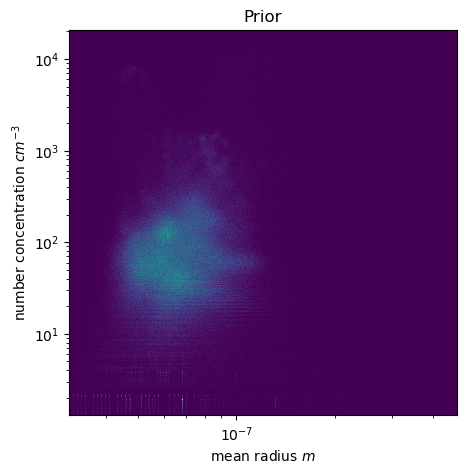

In [29]:
hist_ax = np.exp(y_rescale_lst[-1].unscale(np.stack([0.5*(h_part_total[1][:-1]+h_part_total[1][1:]),
                                                0.5*(h_part_total[2][:-1]+h_part_total[2][1:])],axis=1)))

fig,ax = plt.subplots(1,1,figsize=(5,5))
# ax = ax_lst[m_idx]
ax.pcolormesh(hist_ax[:,1],hist_ax[:,0],h_part_total[0].T/np.sum(h_part_total[0]))
ax.set_xscale('log')
ax.set_yscale('log')
# if m_idx//n_col == 1:
ax.set_xlabel(r'mean radius $m$')
# if m_idx%n_col == 0:
ax.set_ylabel(r'number concentration $cm^{-3}$')
# title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
ax.set_title("Prior")

Text(0.5, 0, 'Concentration [$cm^{-3}$]')

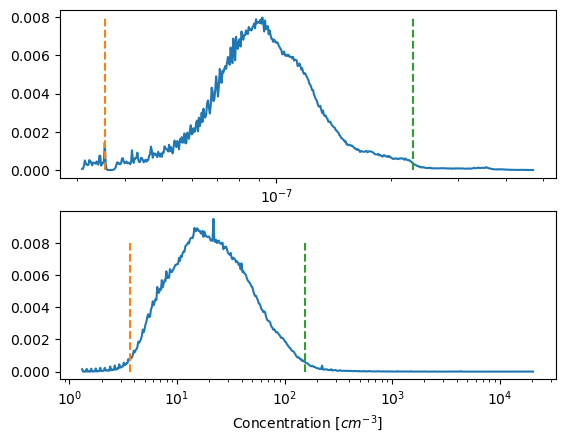

In [30]:
hist_ax = np.exp(y_rescale_lst[-1].unscale(np.stack([0.5*(h_part_total[1][:-1]+h_part_total[1][1:]),
                                                0.5*(h_part_total[2][:-1]+h_part_total[2][1:])],axis=1)))

fig, ax = plt.subplots(2,1)
ax[0].plot(hist_ax[:,1],np.sum(h_part_total[0],axis=0)/np.sum(h_part_total[0]))
ax[0].plot(np.exp(np.array(2*[percentile_prior_ln_lst[0][0][0,1]])),[0,0.008],'--')
ax[0].plot(np.exp(np.array(2*[percentile_prior_ln_lst[0][1][0,1]])),[0,0.008],'--')
ax[0].set_xscale('log')
ax[0].set_xlabel('Particle Radius [m]')

ax[1].plot(hist_ax[:,0],np.sum(h_part_total[0],axis=1)/np.sum(h_part_total[0]))
ax[1].plot(np.exp(np.array(2*[percentile_prior_ln_lst[0][0][0,0]])),[0,0.008],'--')
ax[1].plot(np.exp(np.array(2*[percentile_prior_ln_lst[0][1][0,0]])),[0,0.008],'--')
ax[1].set_xscale('log')
ax[1].set_xlabel('Concentration [$cm^{-3}$]')

In [31]:
len(hr_lst)

8

Normalize the histogram to the prior?  Is there a way to make a histogram of the spread in radius or number density across all data?

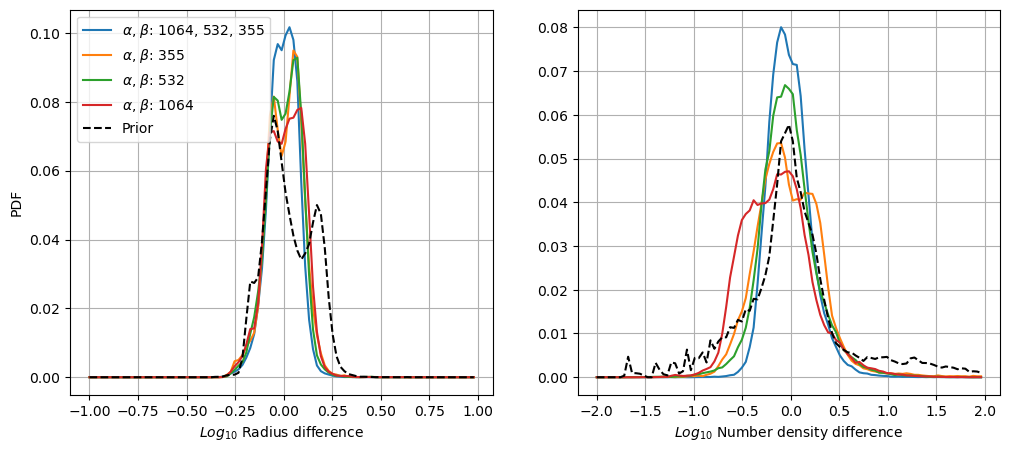

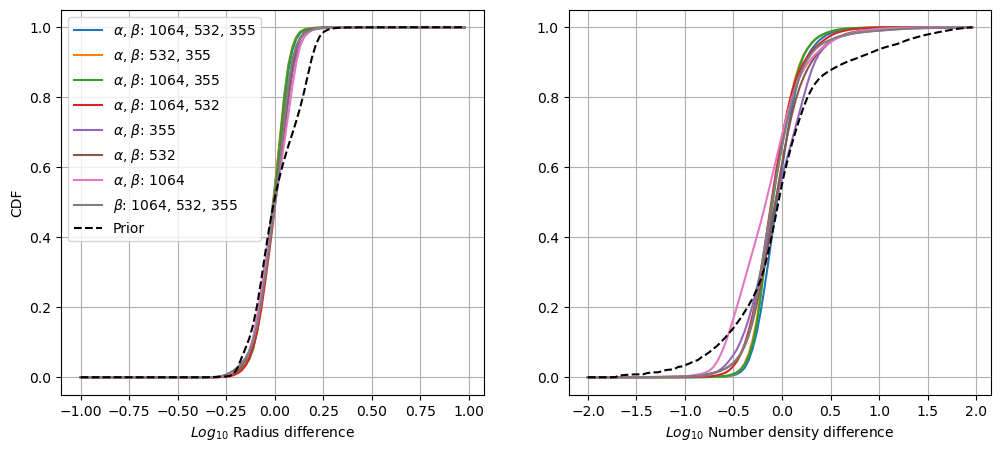

In [32]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
plt_lst = [0,4,5,6,]
for m_idx, hr in enumerate(hr_lst):
    if m_idx in plt_lst:
        label = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
        ax[0].plot(hr[1][:-1],hr[0]/np.sum(hr[0]),label=label)
    
    
        hn = hn_lst[m_idx]
        ax[1].plot(hn[1][:-1],hn[0]/np.sum(hn[0]),label=label)

ax[0].plot(hr_prior[1][:-1],hr_prior[0]/np.sum(hr_prior[0]),label="Prior",color='k',linestyle='--')

ax[0].set_xlabel('$Log_{10}$ Radius difference')
ax[0].grid(visible=True)
ax[0].set_ylabel("PDF")
ax[0].legend()

ax[1].plot(hn_prior[1][:-1],hn_prior[0]/np.sum(hn_prior[0]),label="Prior",color='k',linestyle='--')
ax[1].set_xlabel('$Log_{10}$ Number density difference')
ax[1].grid(visible=True)

fig,ax = plt.subplots(1,2,figsize=(12,5))
for m_idx, hr in enumerate(hr_lst):
    label = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax[0].plot(hr[1][:-1],np.cumsum(hr[0]/np.sum(hr[0])),label=label)
    

    hn = hn_lst[m_idx]
    ax[1].plot(hn[1][:-1],np.cumsum(hn[0]/np.sum(hn[0])),label=label)

ax[0].plot(hr_prior[1][:-1],np.cumsum(hr_prior[0]/np.sum(hr_prior[0])),label="Prior",color='k',linestyle='--')

ax[0].set_xlabel('$Log_{10}$ Radius difference')
ax[0].grid(visible=True)
ax[0].set_ylabel("CDF")
ax[0].legend()

ax[1].plot(hn_prior[1][:-1],np.cumsum(hn_prior[0]/np.sum(hn_prior[0])),label="Prior",color='k',linestyle='--')

ax[1].set_xlabel('$Log_{10}$ Number density difference')
ax[1].grid(visible=True)
    

In [33]:
10**(0.5*np.log10(np.exp(1)))

1.6487212707001282

Text(0.5, 1.0, 'Prior')

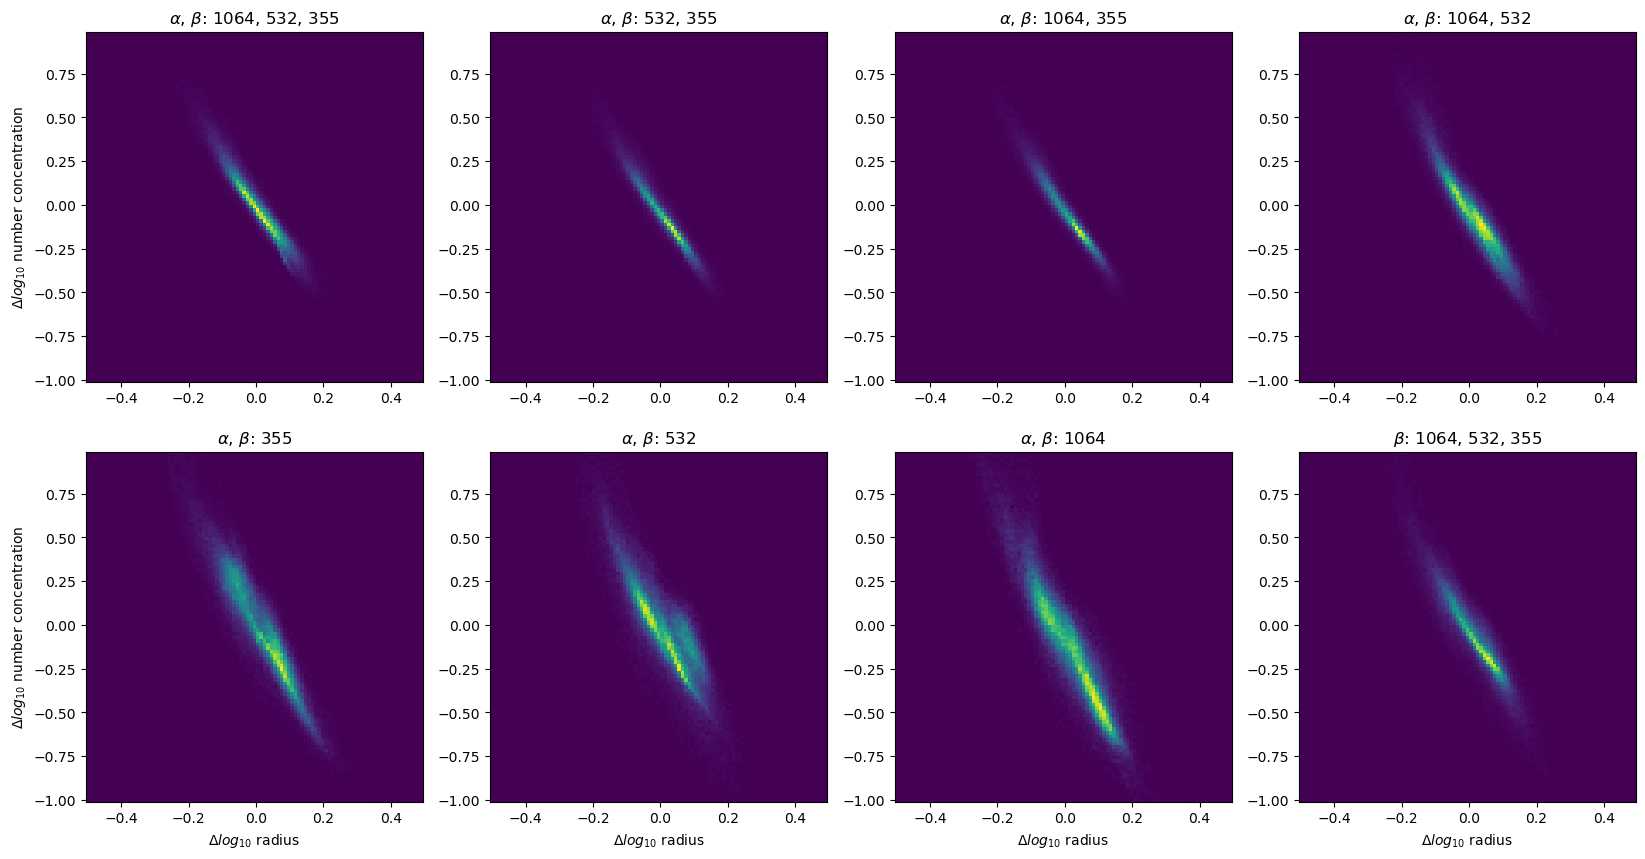

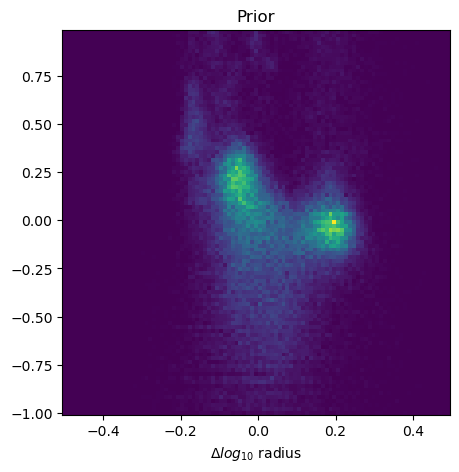

In [34]:
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hcmb in enumerate(hcmb_lst):
    ax = ax_lst[m_idx]
    ax.pcolormesh(hcmb[1][:-1],hcmb[2][:-1],hcmb[0].T/np.sum(hcmb[0]))
    if m_idx//n_col == 1:
        ax.set_xlabel(r'$\Delta log_{10}$ radius')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'$\Delta log_{10}$ number concentration')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)



fig,ax = plt.subplots(1,1,figsize=(5*1,5*1))

ax.pcolormesh(hcmb_prior[1][:-1],hcmb_prior[2][:-1],hcmb_prior[0].T/np.sum(hcmb_prior[0]))
if m_idx//n_col == 1:
    ax.set_xlabel(r'$\Delta log_{10}$ radius')
if m_idx%n_col == 0:
    ax.set_ylabel(r'$\Delta log_{10}$ number concentration')
title = 'Prior'
ax.set_title(title)

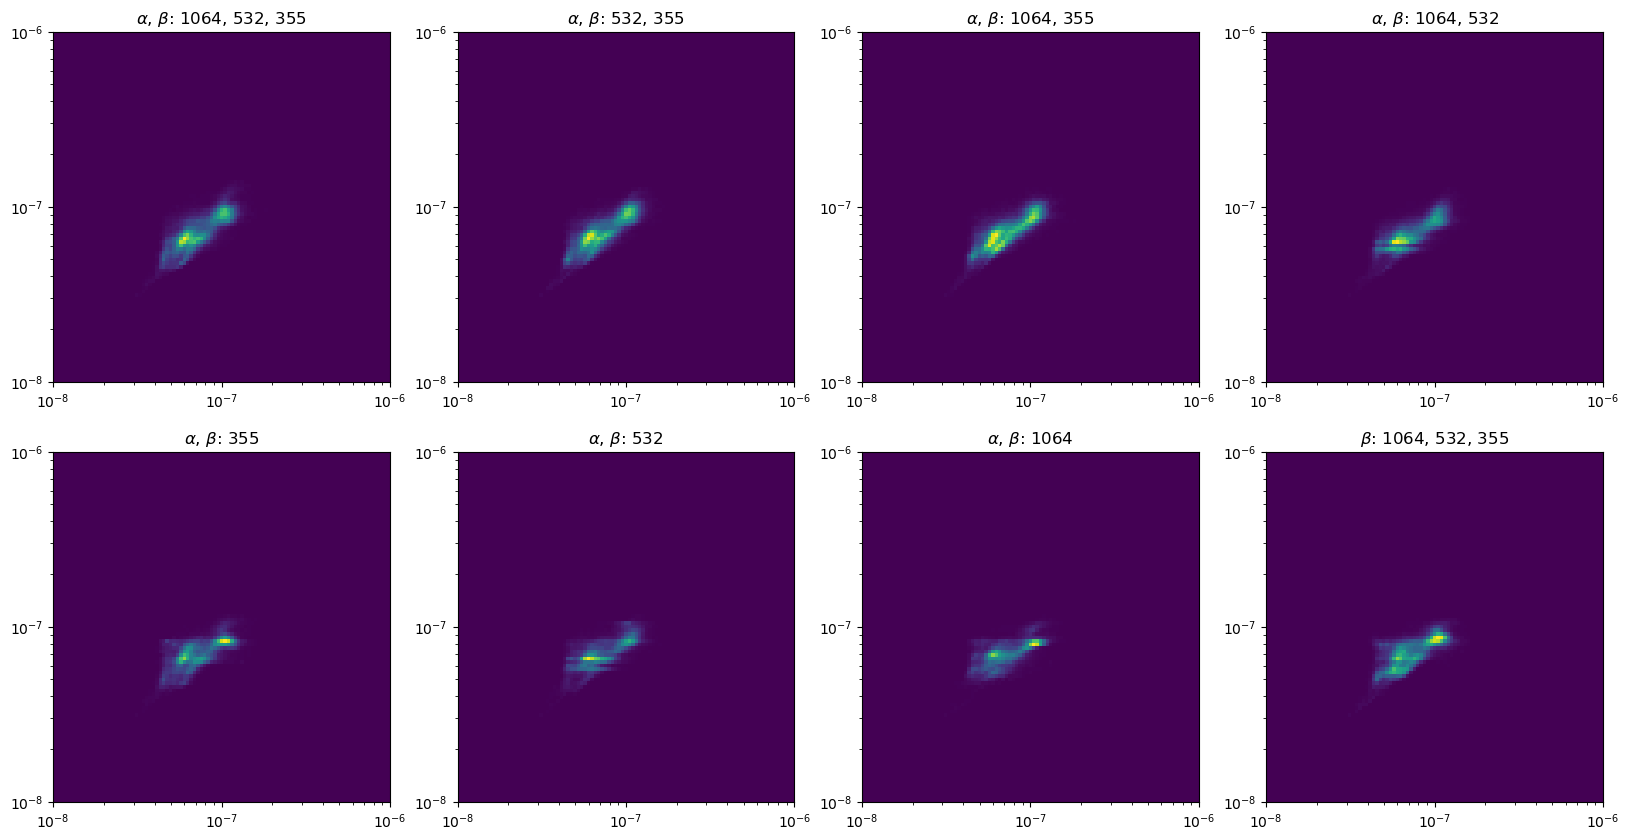

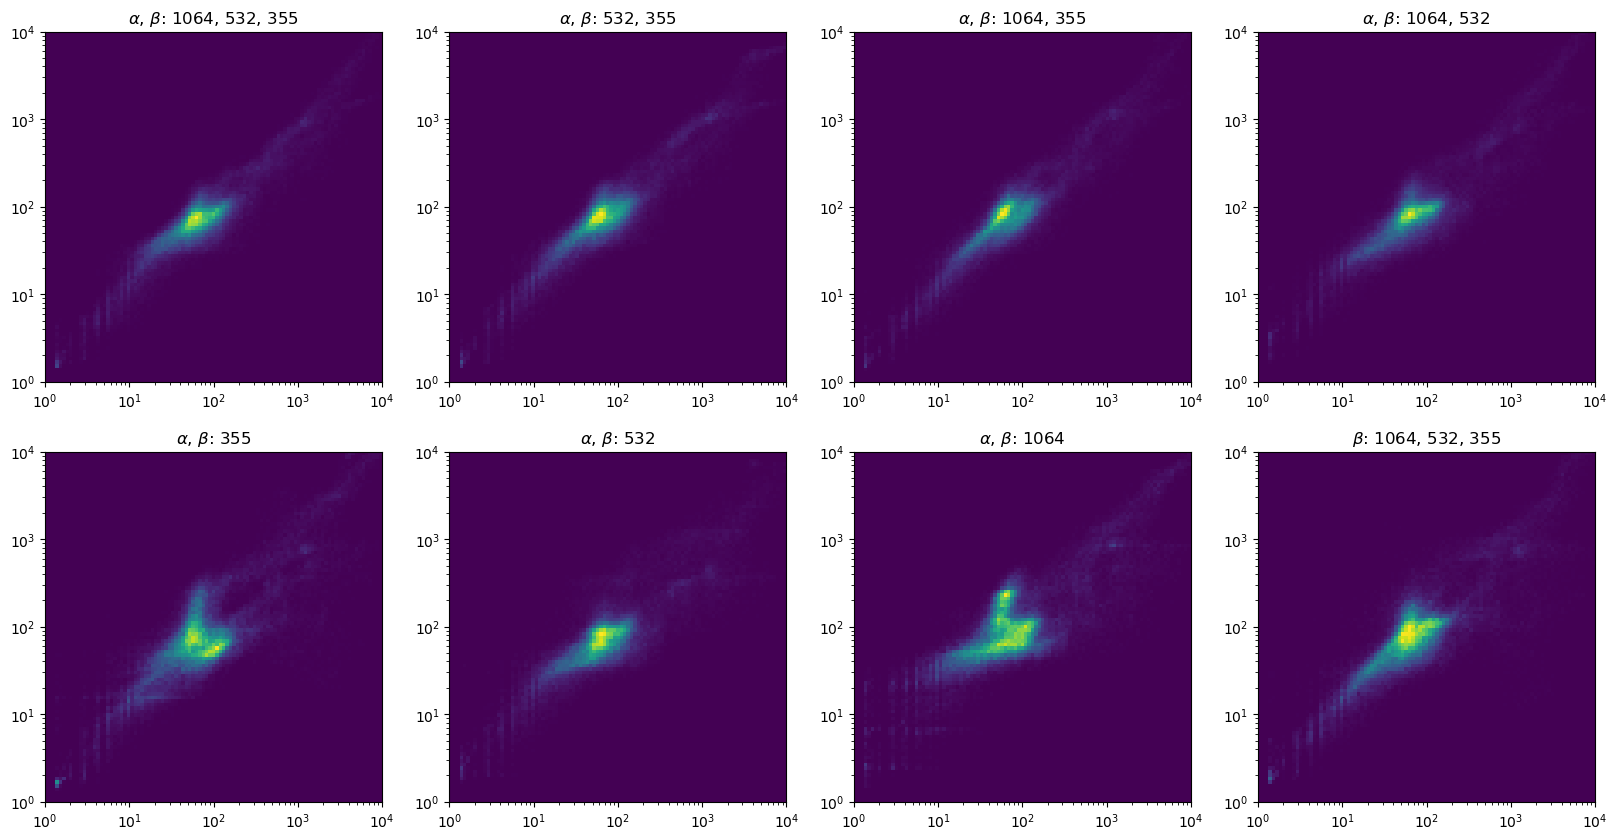

In [35]:

n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hr_2d in enumerate(hr_2d_lst):
    ax = ax_lst[m_idx]
    ax.pcolormesh(hr_2d[1],hr_2d[2],hr_2d[0].T/np.sum(hr_2d[0]))
    ax.set_xscale('log')
    ax.set_yscale('log')
    # if m_idx//3 == 1:
    #     ax.set_xlabel(r'$\Delta log_{10}$ radius')
    # if m_idx%3 == 0:
    #     ax.set_ylabel(r'$\Delta log_{10}$ number concentration')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)


n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hn_2d in enumerate(hn_2d_lst):
    ax = ax_lst[m_idx]
    ax.pcolormesh(hn_2d[1],hn_2d[2],hn_2d[0].T/np.sum(hn_2d[0]))
    ax.set_xscale('log')
    ax.set_yscale('log')
    # if m_idx//3 == 1:
    #     ax.set_xlabel(r'$\Delta log_{10}$ radius')
    # if m_idx%3 == 0:
    #     ax.set_ylabel(r'$\Delta log_{10}$ number concentration')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

Note that the ballooning of uncertainty in particle radius is probably a product of the finite resolution of the UHSAS bins.  At small particle sizes, the uncertainty is small on a log scale because large relative differences in particle sizes end up in the same UHSAS bin.

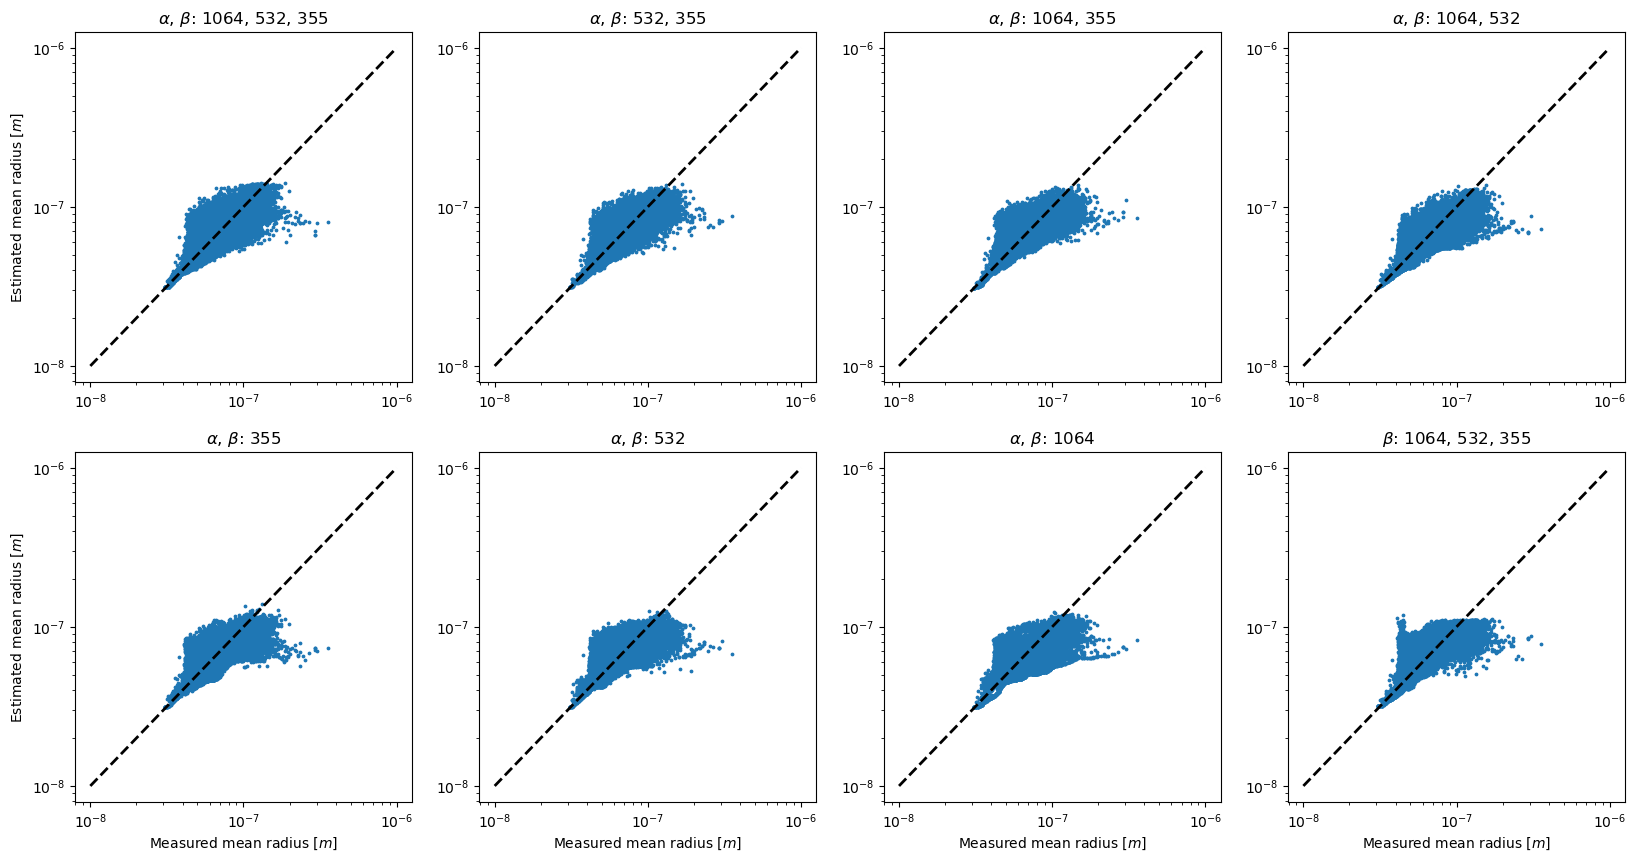

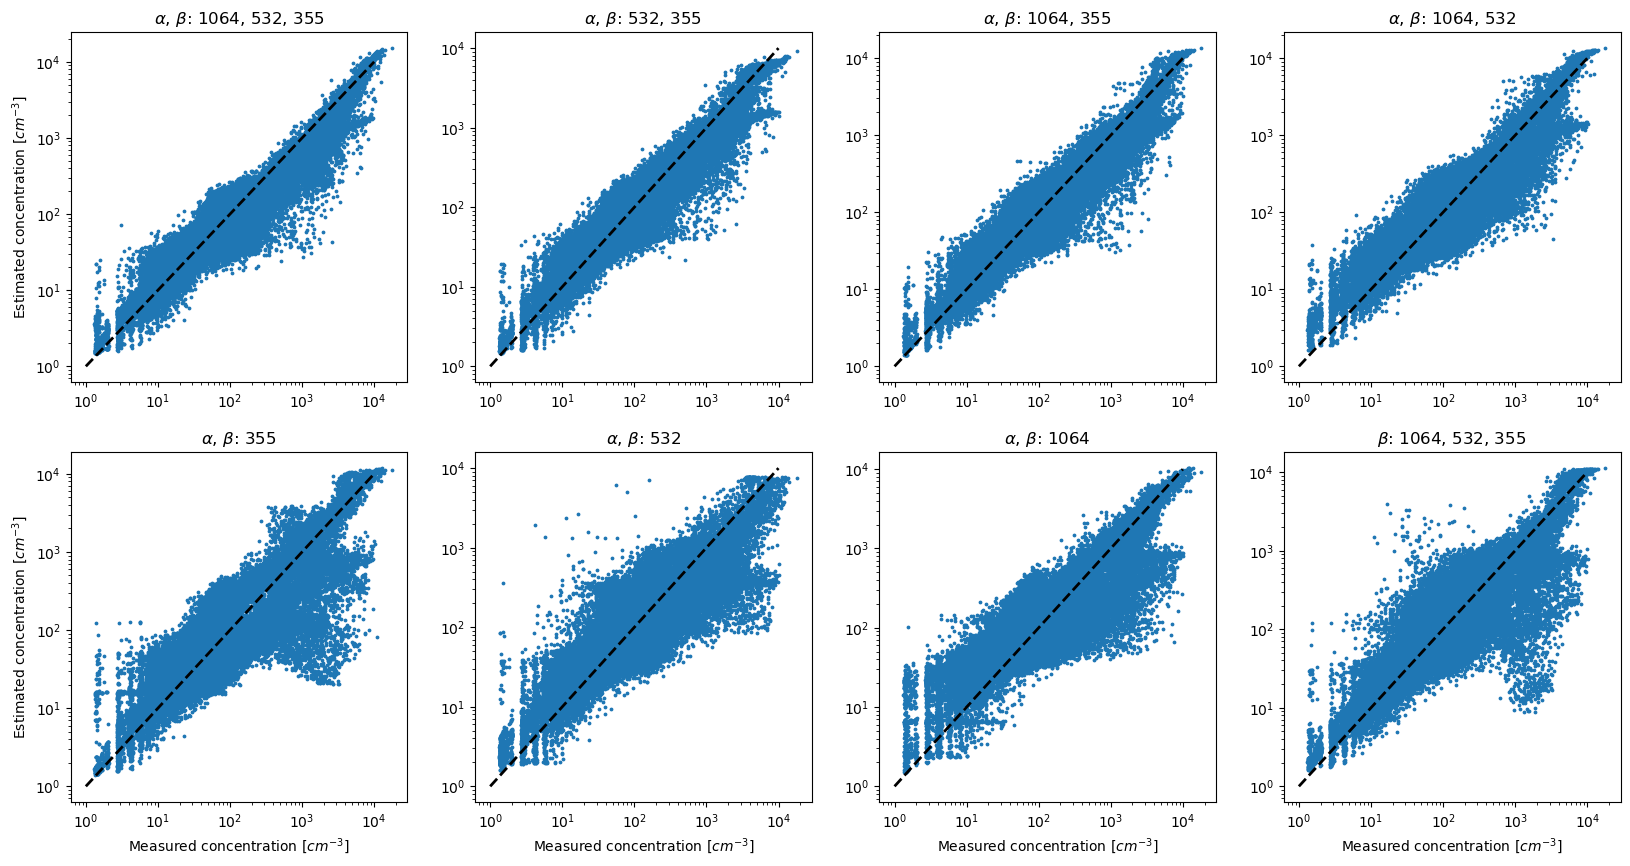

In [35]:

n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    ax = ax_lst[m_idx]
    ax.scatter(np.exp(act_data_ln[:,1]),np.exp(centroid_data_ln[:,1]),s=3)
    ax.plot([1e-8,1e-6],[1e-8,1e-6],'k--',linewidth=2)
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'Measured mean radius [$m$]')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Estimated mean radius [$m$]')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)


n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    ax = ax_lst[m_idx]
    ax.scatter(np.exp(act_data_ln[:,0]),np.exp(centroid_data_ln[:,0]),s=3)
    ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'Measured concentration [$cm^{-3}$]')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Estimated concentration [$cm^{-3}$]')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

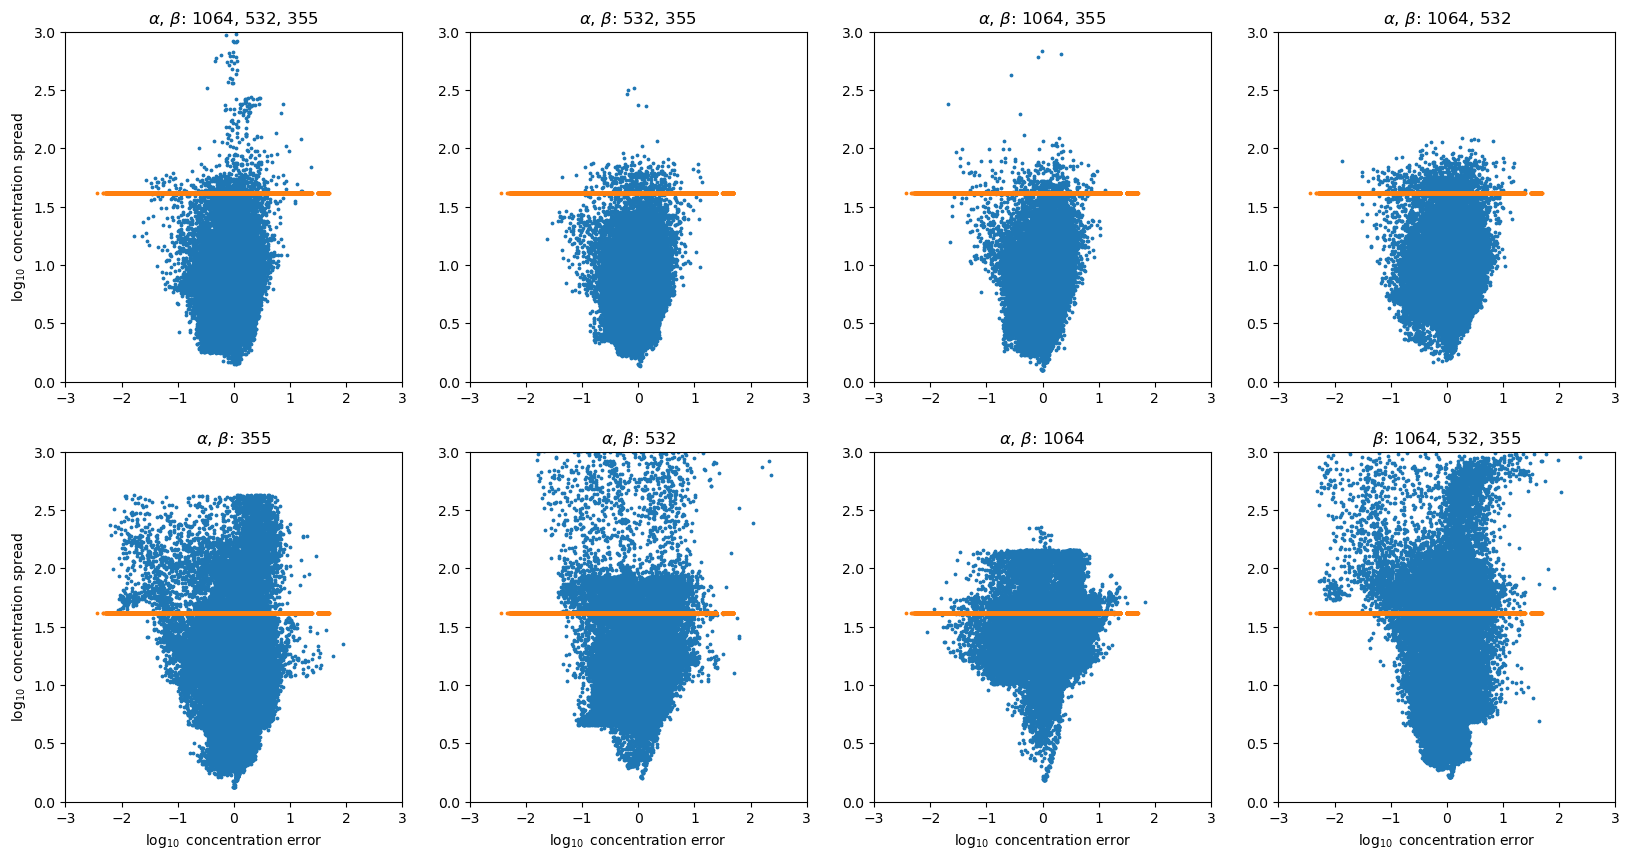

In [41]:
percentile_idx = 0
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    ax.scatter((centroid_data_ln[:,0]-act_data_ln[:,0])*np.log10(np.exp(1)),percentile_delta,s=3)

    ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'$\log_{10}$ concentration error')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'$\log_{10}$ concentration spread')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)
    ax.set_xlim([-3,3])
    ax.set_ylim([0,3])

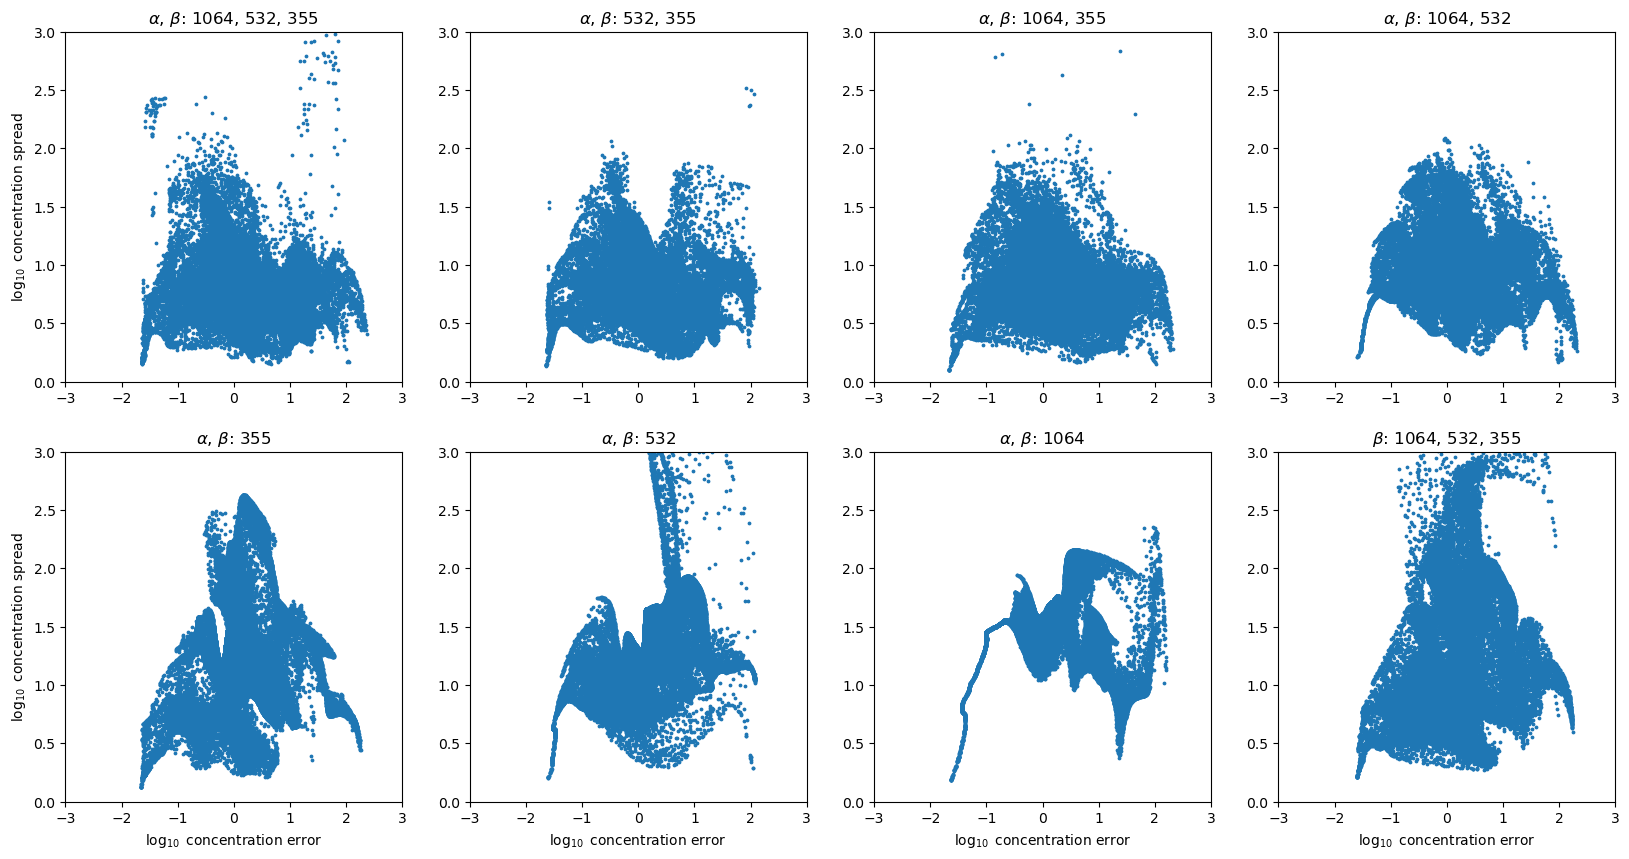

In [42]:
percentile_idx = 0
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    # ax.scatter((centroid_data_ln[:,0]-act_data_ln[:,0])*np.log10(np.exp(1)),percentile_delta,s=3)
    ax.scatter(((centroid_data_ln[:,0]-act_data_ln[:,0])-(np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0]))*np.log10(np.exp(1)),percentile_delta,s=3)

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'$\log_{10}$ concentration error')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'$\log_{10}$ concentration spread')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)
    ax.set_xlim([-3,3])
    ax.set_ylim([0,3])

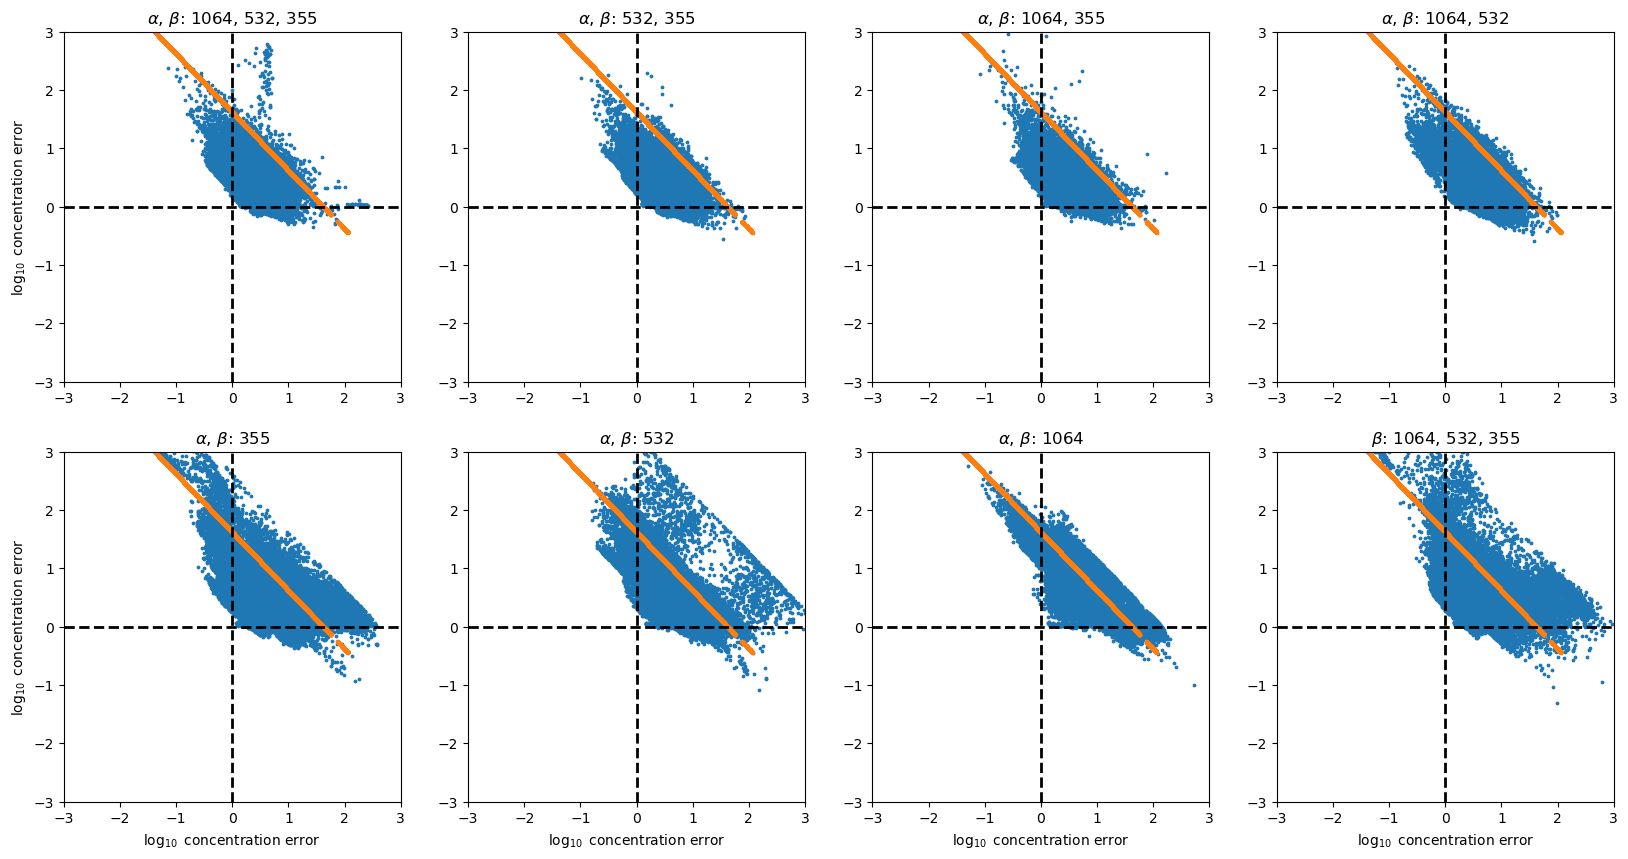

In [37]:
percentile_idx = 0
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    ax.scatter((percentile_data_ln_lst_lst[m_idx][percentile_idx][1][:,0]-act_data_ln[:,0])*np.log10(np.exp(1)),
               (act_data_ln[:,0]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0][:,0])*np.log10(np.exp(1)),s=3)

    ax.scatter((percentile_prior_ln_lst[percentile_idx][1][0,0]-act_data_ln[:,0])*np.log10(np.exp(1)),
               (act_data_ln[:,0]-percentile_prior_ln_lst[percentile_idx][0][0,0])*np.log10(np.exp(1)),s=3,c='tab:orange')

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    ax.plot([-3,3],[0,0],'k--',linewidth=2)
    ax.plot([0,0],[-3,3],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'$\log_{10}$ concentration error')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'$\log_{10}$ concentration error')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)
    ax.set_xlim([-3,3])
    ax.set_ylim([-3,3])

(-5.0, 5.0)

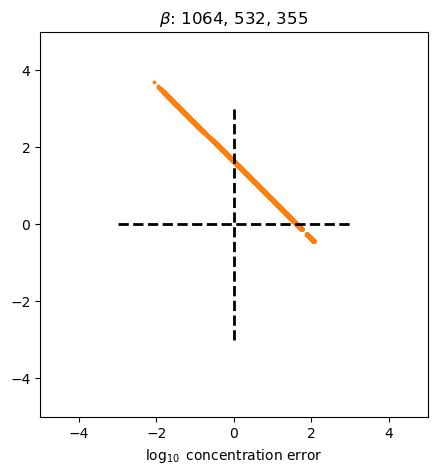

In [38]:
fig,ax = plt.subplots(1,1,figsize=(5,5))

ax.scatter((percentile_prior_ln_lst[percentile_idx][1][0,0]-act_data_ln[:,0])*np.log10(np.exp(1)),
               (act_data_ln[:,0]-percentile_prior_ln_lst[percentile_idx][0][0,0])*np.log10(np.exp(1)),s=3,c='tab:orange')

# ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
# x_ax_lim = ax.get_xlim()
# ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
#         [prior_percentile_delta[0,0]]*2,
#         'k--')
ax.plot([-3,3],[0,0],'k--',linewidth=2)
ax.plot([0,0],[-3,3],'k--',linewidth=2)
# ax.set_xscale('log')
# ax.set_yscale('log')
if m_idx//n_col == 1:
    ax.set_xlabel(r'$\log_{10}$ concentration error')
if m_idx%n_col == 0:
    ax.set_ylabel(r'$\log_{10}$ concentration error')
title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
ax.set_title(title)
ax.set_xlim([-5,5])
ax.set_ylim([-5,5])

In [39]:
percentile_delta = (percentile_data_ln_lst_lst[0][percentile_idx][1]-percentile_data_ln_lst_lst[0][percentile_idx][0])*np.log10(np.exp(1))
percentile_delta = percentile_delta[:,0]
np.where(percentile_delta > prior_percentile_delta[0,0])

(array([   14,   280,   287,   295,   421,   455,   617,  2112,  3092,
         3678,  3686,  3733,  3795,  3854,  3933,  3939,  3959,  3986,
         4066,  4557,  4669,  4680,  4778,  4805,  4834,  4860,  8665,
         9682,  9790,  9907, 10116, 10298, 10499, 10574, 10701, 10776,
        10792, 10964, 11186, 11204, 11241, 11319, 11412, 11606, 11717,
        13340, 13388, 13796, 13903, 13906, 14055, 15137, 15233, 15697,
        15831, 16195, 16299, 16448, 16776, 16844, 16880, 16935, 16989,
        17715, 17726, 18413, 18630, 18717, 19998, 20524, 20812, 21183,
        21884, 21937, 21959, 22079, 22117, 22124, 22155, 22222, 22231,
        22233, 22271, 22287, 22374, 22426, 22451, 22554, 22629, 22680,
        22683, 22710, 22712, 22745, 22842, 22871, 23307, 23420, 23421,
        23422, 23438, 23844, 23854, 23857, 24275, 24276, 24357, 24494,
        25259, 25314, 25378, 25399, 25407, 25458, 25462, 26875, 27757,
        27782, 28407, 30350, 30422, 30423, 30549, 30710, 30879, 31082,
      

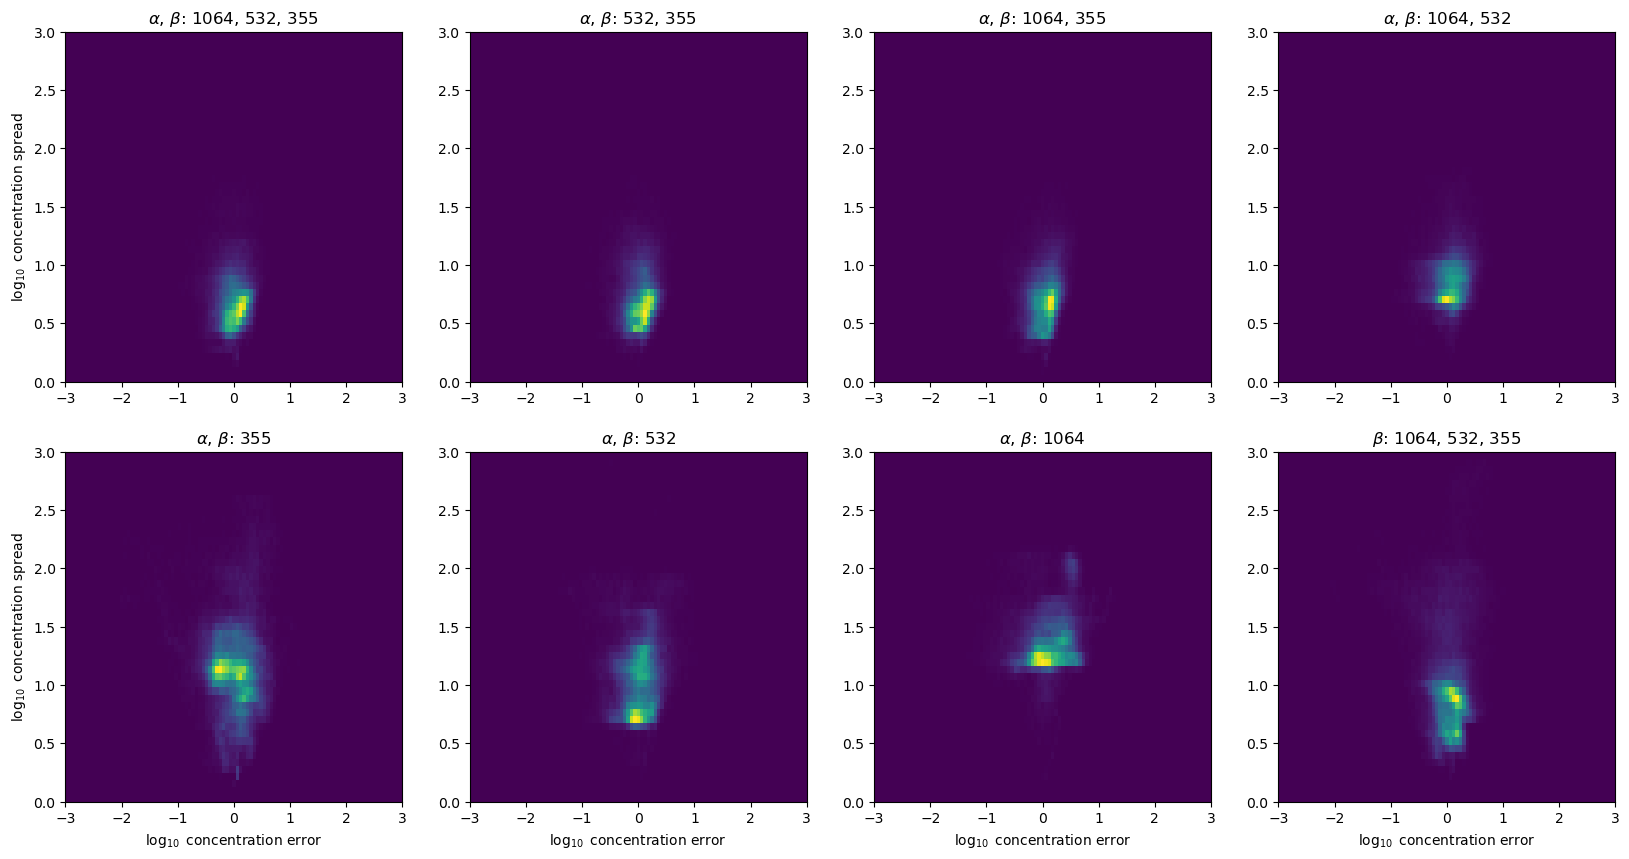

In [40]:
percentile_idx = 0
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    hists = np.histogram2d((centroid_data_ln[:,0]-act_data_ln[:,0])*np.log10(np.exp(1)),percentile_delta,
                bins=(np.linspace(-3,3,100),np.linspace(0,3,50)))
    ax.pcolormesh(hists[1],hists[2],hists[0].T)

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'$\log_{10}$ concentration error')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'$\log_{10}$ concentration spread')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)
    ax.set_xlim([-3,3])
    ax.set_ylim([0,3])

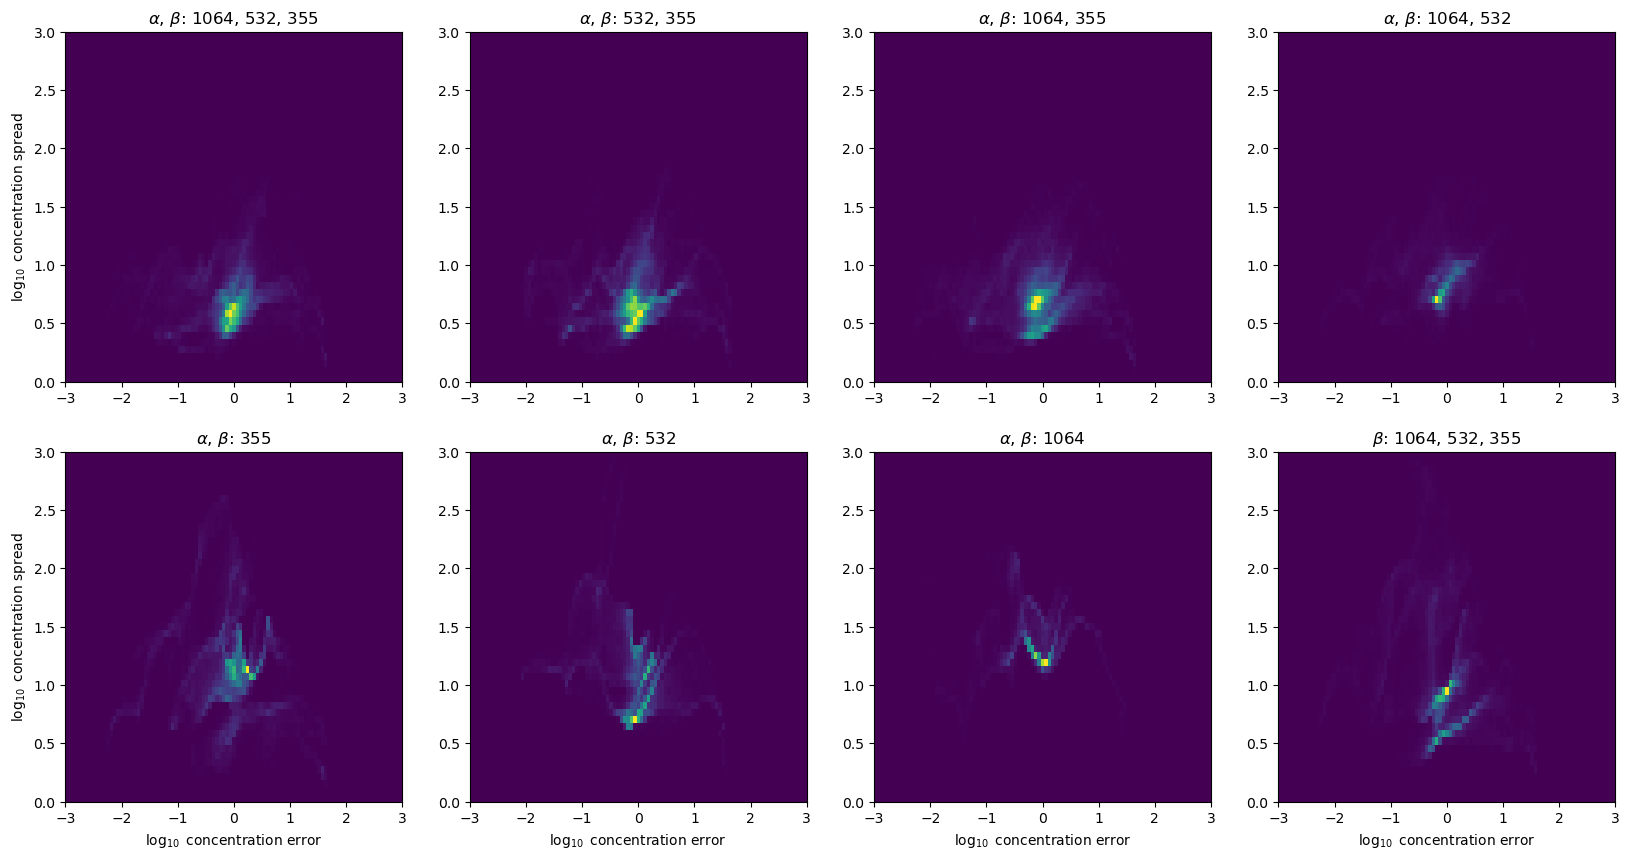

In [43]:
percentile_idx = 0
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    hists = np.histogram2d(((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])-(centroid_data_ln[:,0]-act_data_ln[:,0]))*np.log10(np.exp(1)),percentile_delta,
                bins=(np.linspace(-3,3,100),np.linspace(0,3,50)))
    ax.pcolormesh(hists[1],hists[2],hists[0].T)

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'$\log_{10}$ concentration error')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'$\log_{10}$ concentration spread')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)
    ax.set_xlim([-3,3])
    ax.set_ylim([0,3])

Text(0.5, 1.0, '$\\alpha$, $\\beta$: 1064, 532, 355')

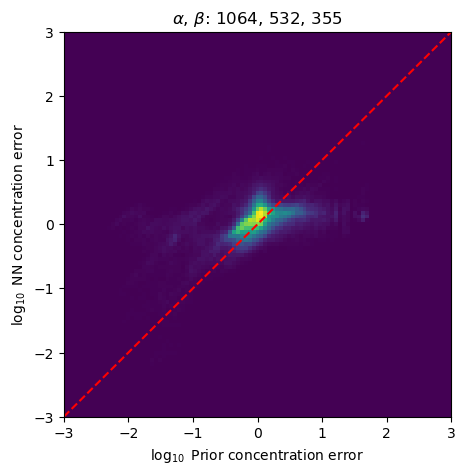

In [62]:
percentile_idx = 0
n_col = 1
n_row = 1 #int(np.ceil(len(hcmb_lst)/n_col))
m_idx= 0

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
# ax_lst = ax_lst.ravel()
# for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
act_data_ln = act_data_ln_lst[m_idx]
percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
percentile_delta = percentile_delta[:,0]
ax = ax_lst
# hists = np.histogram2d(((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])-(centroid_data_ln[:,0]-act_data_ln[:,0]))*np.log10(np.exp(1)),percentile_delta,
#             bins=(np.linspace(-2,2,100),np.linspace(0,3,50)))

hists = np.histogram2d((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),(centroid_data_ln[:,0]-act_data_ln[:,0])*np.log10(np.exp(1)),
            bins=(np.linspace(-3,3,100),np.linspace(-3,3,100)))

ax.pcolormesh(hists[1],hists[2],hists[0].T)
ax.plot([-3,3],[-3,3],'r--')

# ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
# x_ax_lim = ax.get_xlim()
# ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
#         [prior_percentile_delta[0,0]]*2,
#         'k--')
# ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
# ax.set_xscale('log')
# ax.set_yscale('log')
# if m_idx//n_col == 1:
ax.set_xlabel(r'$\log_{10}$ Prior concentration error')
# if m_idx%n_col == 0:
ax.set_ylabel(r'$\log_{10}$ NN concentration error')
title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
ax.set_title(title)
# ax.set_xlim([-3,3])
# ax.set_ylim([0,3])

In [58]:
np.sum(hists[0])

0.0

In [54]:
(np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1))

array([-1.20358265, -1.12413447, -1.09717371, ..., -0.97037865,
       -0.96693623, -1.04556331])

In [55]:
(centroid_data_ln[:,0]-act_data_ln[:,0])*np.log10(np.exp(1))

array([-0.56041289, -0.76542405, -0.75121414, ..., -0.61762368,
       -0.83292152, -0.79522261])

5-95 %
5-95 %
5-95 %
5-95 %


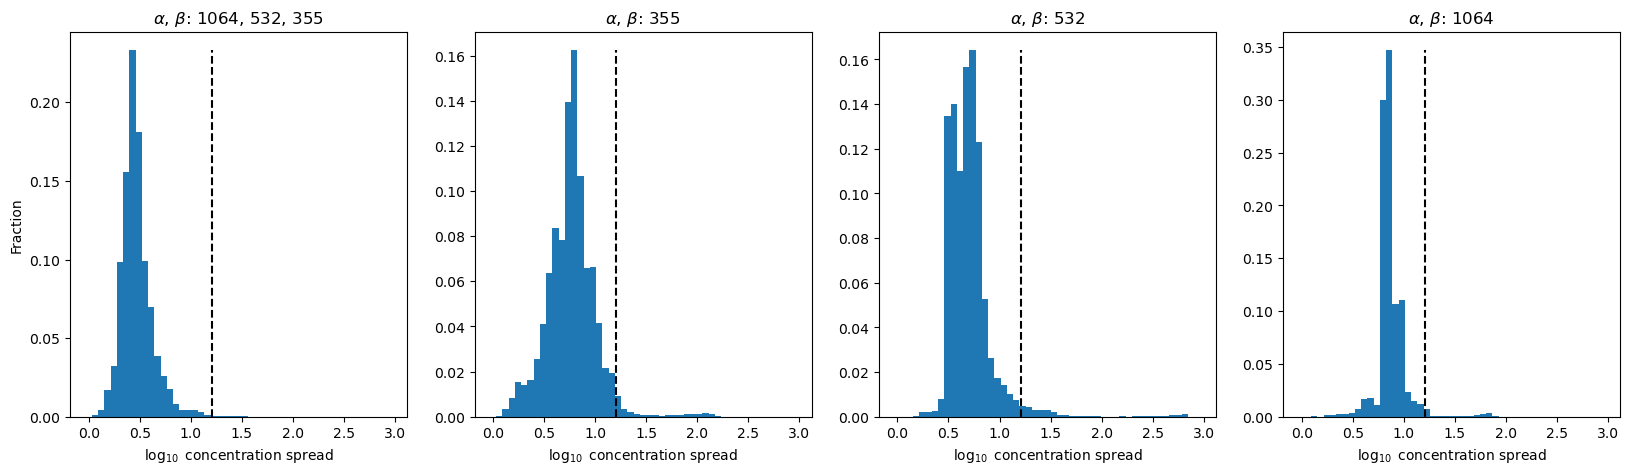

In [37]:
percentile_idx = 1
plt_lst = [0,4,5,6,]
n_col = 4
# n_row = int(np.ceil(len(hcmb_lst)/n_col))
n_row = int(np.ceil(len(plt_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
# for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
for m_idx, pidx in enumerate(plt_lst):
    centroid_data_ln = centroid_data_ln_lst[pidx]
    act_data_ln = act_data_ln_lst[pidx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,3,50))
    # x_axis_plt = 10**(hists[1][:-1])
    x_axis_plt = hists[1][:-1]
    ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(hists[1]))

    ax.plot(2*[prior_percentile_delta[0,0]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # if m_idx//n_col == 1:
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'$\log_{10}$ concentration spread')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Fraction')
    title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    ax.set_title(title)
    # ax.set_xlim([0,20])
    # ax.set_ylim([0,3])

5-95 %
5-95 %
5-95 %
5-95 %


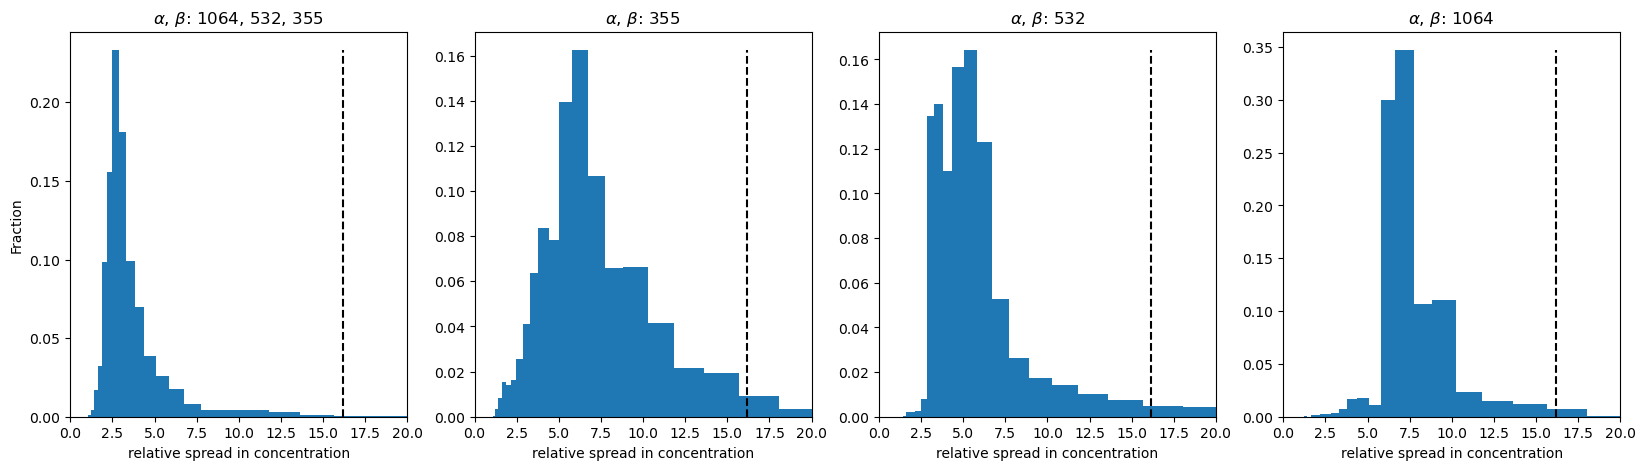

In [39]:
percentile_idx = 1
plt_lst = [0,4,5,6,]
n_col = 4
# n_row = int(np.ceil(len(hcmb_lst)/n_col))
n_row = int(np.ceil(len(plt_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
# for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
for m_idx, pidx in enumerate(plt_lst):
    centroid_data_ln = centroid_data_ln_lst[pidx]
    act_data_ln = act_data_ln_lst[pidx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,3,50))
    x_axis_plt = 10**(hists[1][:-1])
    # x_axis_plt = hists[1][:-1]
    ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(10**hists[1]))

    ax.plot(2*[10**prior_percentile_delta[0,0]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # if m_idx//n_col == 1:
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'relative spread in concentration')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Fraction')
    title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    ax.set_title(title)
    ax.set_xlim([0,20])
    # ax.set_ylim([0,3])

In [44]:
m_idx//n_col == n_row-1

True

5-95 %
5-95 %
5-95 %
5-95 %


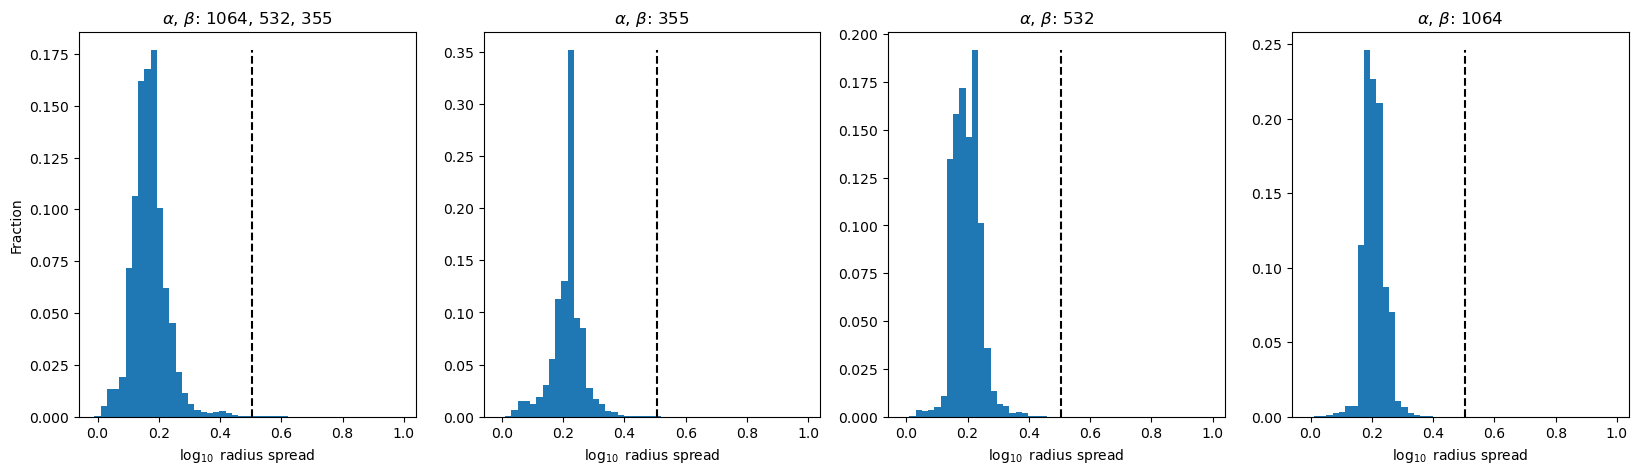

In [40]:
percentile_idx = 1
n_col = 4
# n_row = int(np.ceil(len(hcmb_lst)/n_col))
n_row = int(np.ceil(len(plt_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
# for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
for m_idx, pidx in enumerate(plt_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,1]
    ax = ax_lst[m_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,1,50))
    # x_axis_plt = 10**(hists[1][:-1])
    x_axis_plt = hists[1][:-1]
    ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(hists[1]))

    ax.plot(2*[prior_percentile_delta[0,1]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")
    
    # if m_idx//n_col == 1:
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'$\log_{10}$ radius spread')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Fraction')
    title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    ax.set_title(title)
    # ax.set_xlim([-3,3])
    # ax.set_ylim([0,3])

In [ ]:
percentile_idx = 1
n_col = 4
# n_row = int(np.ceil(len(hcmb_lst)/n_col))
n_row = int(np.ceil(len(plt_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
# for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
for m_idx, pidx in enumerate(plt_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,1]
    ax = ax_lst[m_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,1,50))
    x_axis_plt = 10**(hists[1][:-1])
    # x_axis_plt = hists[1][:-1]
    ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff10**(hists[1]))

    ax.plot(2*[prior_percentile_delta[0,1]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")
    
    # if m_idx//n_col == 1:
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'$\log_{10}$ radius spread')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Fraction')
    title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    ax.set_title(title)
    # ax.set_xlim([-3,3])
    # ax.set_ylim([0,3])

In [43]:
prior_percentile_delta[0,0]

1.6210489693356749

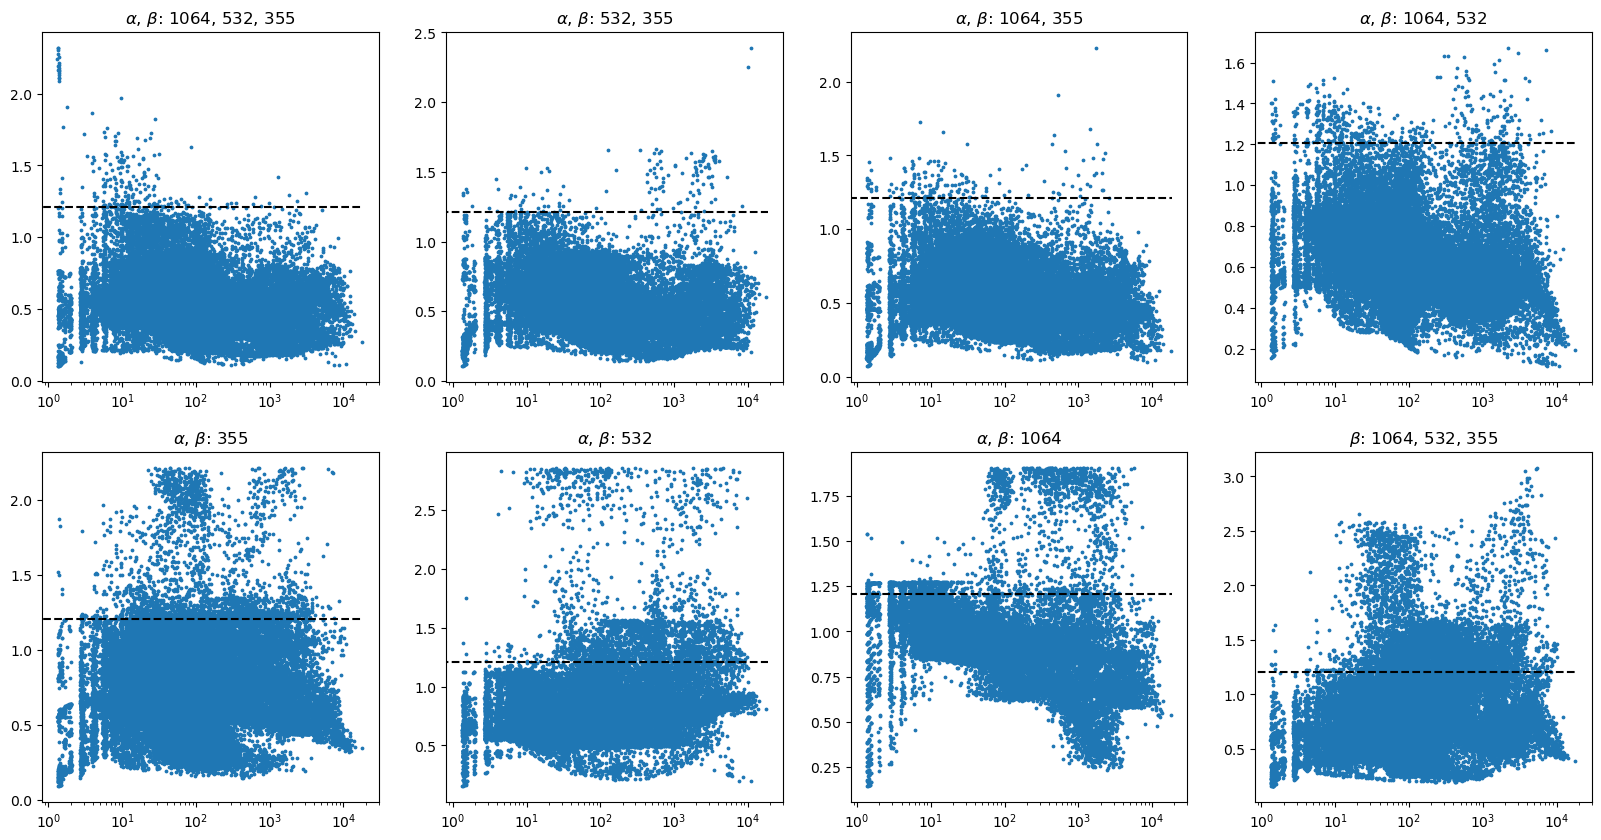

In [44]:
percentile_idx = 1
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    ax.scatter(np.exp(act_data_ln[:,0]),percentile_delta,s=3)
    x_ax_lim = ax.get_xlim()
    ax.plot(x_ax_lim,
            [prior_percentile_delta[0,0]]*2,
            'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    # if m_idx//3 == 1:
    #     ax.set_xlabel(r'$\Delta log_{10}$ radius')
    # if m_idx%3 == 0:
    #     ax.set_ylabel(r'$\Delta log_{10}$ number concentration')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)


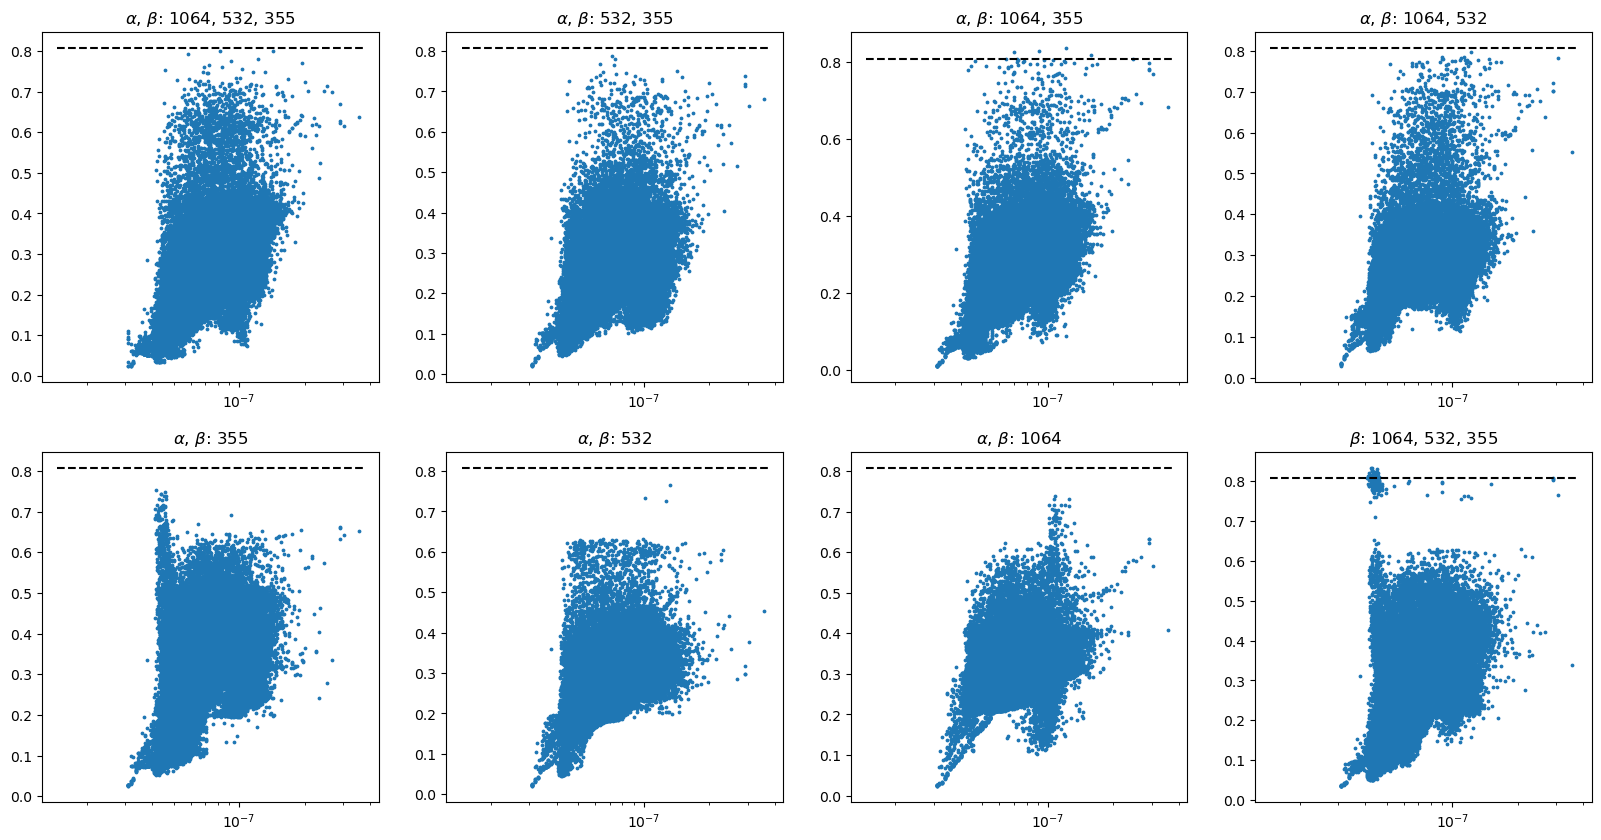

In [45]:
percentile_idx = 0
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,1]
    ax = ax_lst[m_idx]
    ax.scatter(np.exp(act_data_ln[:,1]),percentile_delta,s=3)
    x_ax_lim = ax.get_xlim()
    ax.plot(x_ax_lim,
            [prior_percentile_delta[0,1]]*2,
            'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    # if m_idx//3 == 1:
    #     ax.set_xlabel(r'$\Delta log_{10}$ radius')
    # if m_idx%3 == 0:
    #     ax.set_ylabel(r'$\Delta log_{10}$ number concentration')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

In [46]:
percentile_prior_ln_lst[percentile_idx][1]

array([[  5.0325997 , -15.29450208]])

In [47]:
percentile_prior_ln_lst[percentile_idx][0]

array([[  1.2999965 , -17.15575422]])

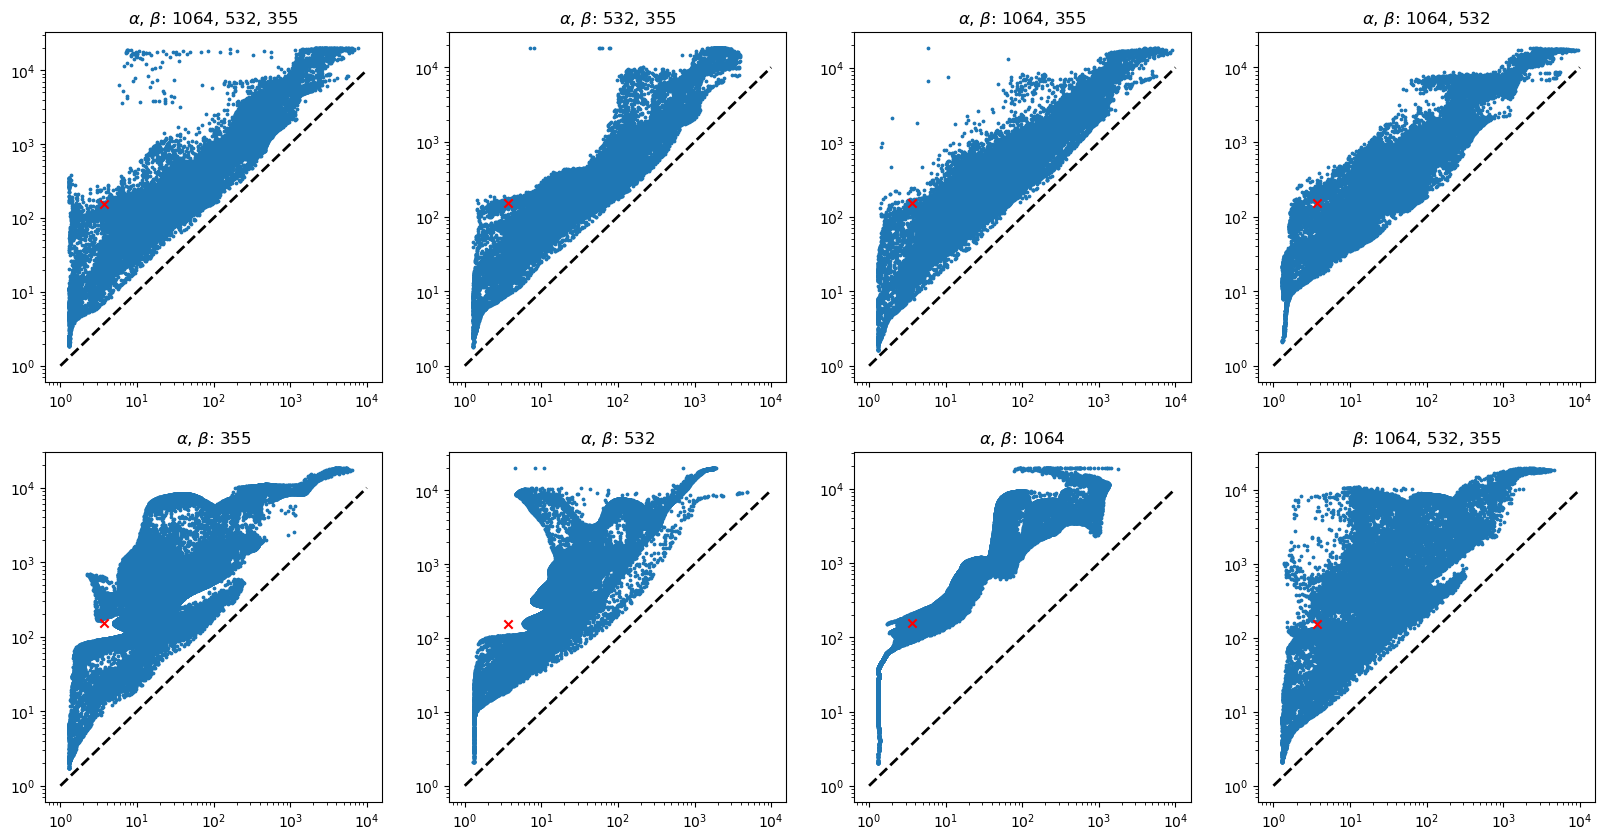

In [48]:
percentile_idx = 0
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
    # act_data_ln = act_data_ln_lst[m_idx]
    # percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
    # percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    ax.scatter(np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][0][:,0]),np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][1][:,0]),s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(x_ax_lim,
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    ax.scatter(np.exp(percentile_prior_ln_lst[percentile_idx][0][0,0]),
               np.exp(percentile_prior_ln_lst[percentile_idx][1][0,0]),c='r',marker='x')
    ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    ax.set_xscale('log')
    ax.set_yscale('log')
    # if m_idx//3 == 1:
    #     ax.set_xlabel(r'$\Delta log_{10}$ radius')
    # if m_idx%3 == 0:
    #     ax.set_ylabel(r'$\Delta log_{10}$ number concentration')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

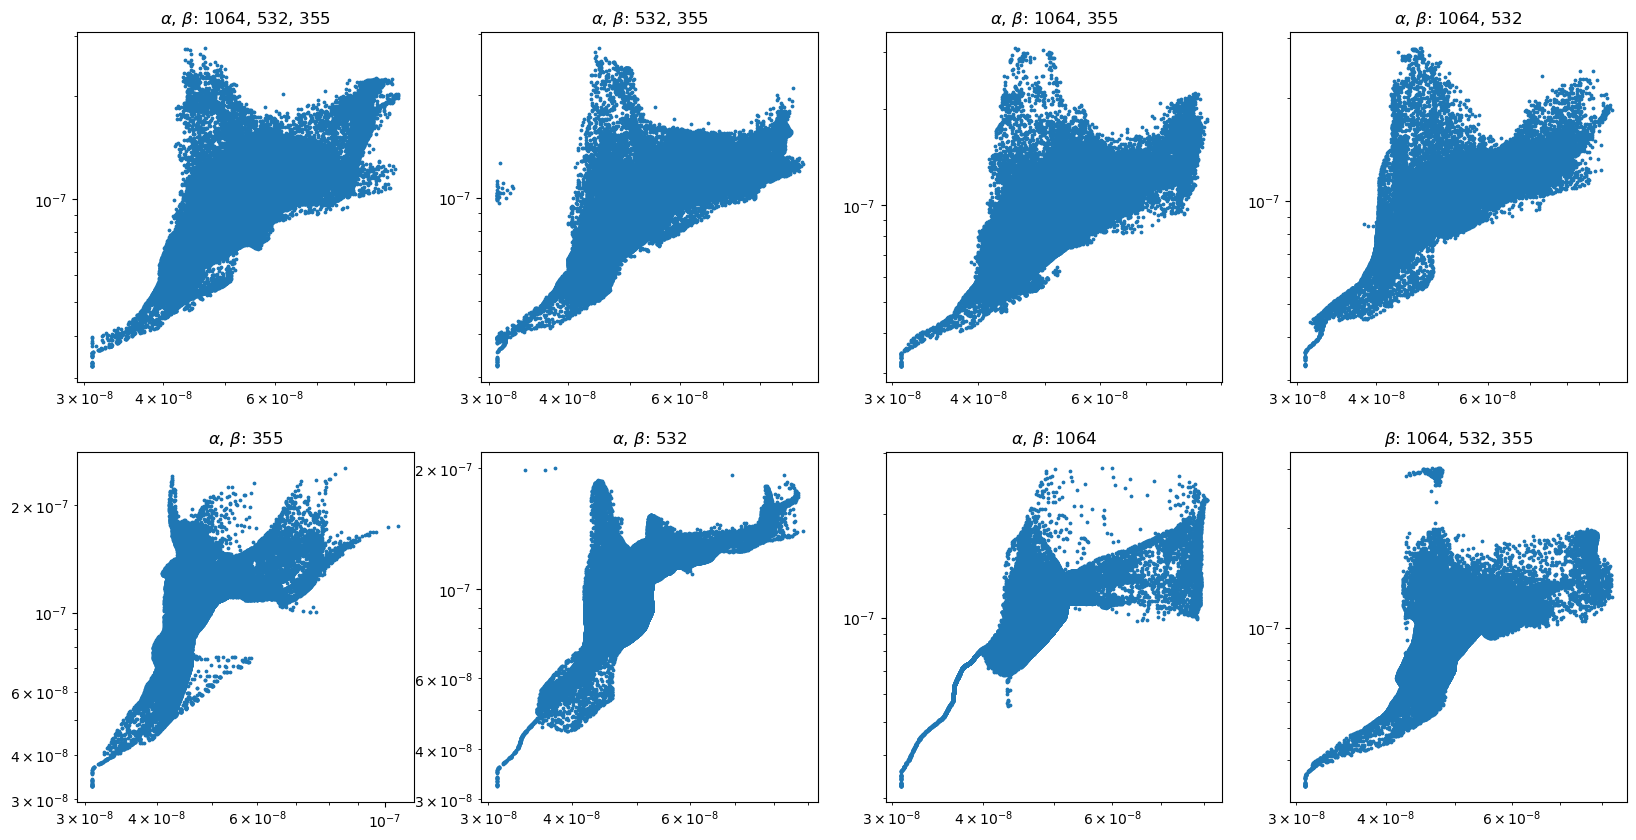

In [49]:
percentile_idx = 0
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
    # act_data_ln = act_data_ln_lst[m_idx]
    # percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
    # percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    ax.scatter(np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][0][:,1]),np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][1][:,1]),s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(x_ax_lim,
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    ax.set_xscale('log')
    ax.set_yscale('log')
    # if m_idx//3 == 1:
    #     ax.set_xlabel(r'$\Delta log_{10}$ radius')
    # if m_idx%3 == 0:
    #     ax.set_ylabel(r'$\Delta log_{10}$ number concentration')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

In [91]:
no_spread_idx = np.where(np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][0][:,1])==np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][1][:,1]))

In [92]:
no_spread_idx[0].size

0

In [93]:
no_spread_idx[1]

IndexError: tuple index out of range

In [ ]:
np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][0])

In [ ]:
# h_part = np.histogram2d(r_sim_hist_lst[m_idx],n_sim_hist_lst[m_idx],bins=np.linspace(0,1,500))

In [ ]:
np.exp(percentile_data_ln_lst_lst[0][percentile_idx][0][idx_arr,np.zeros(idx_arr.size,dtype=int)])

In [ ]:
np.exp(percentile_data_ln_lst_lst[0][percentile_idx][1][idx_arr,np.zeros(idx_arr.size,dtype=int)])

In [ ]:
idx_arr

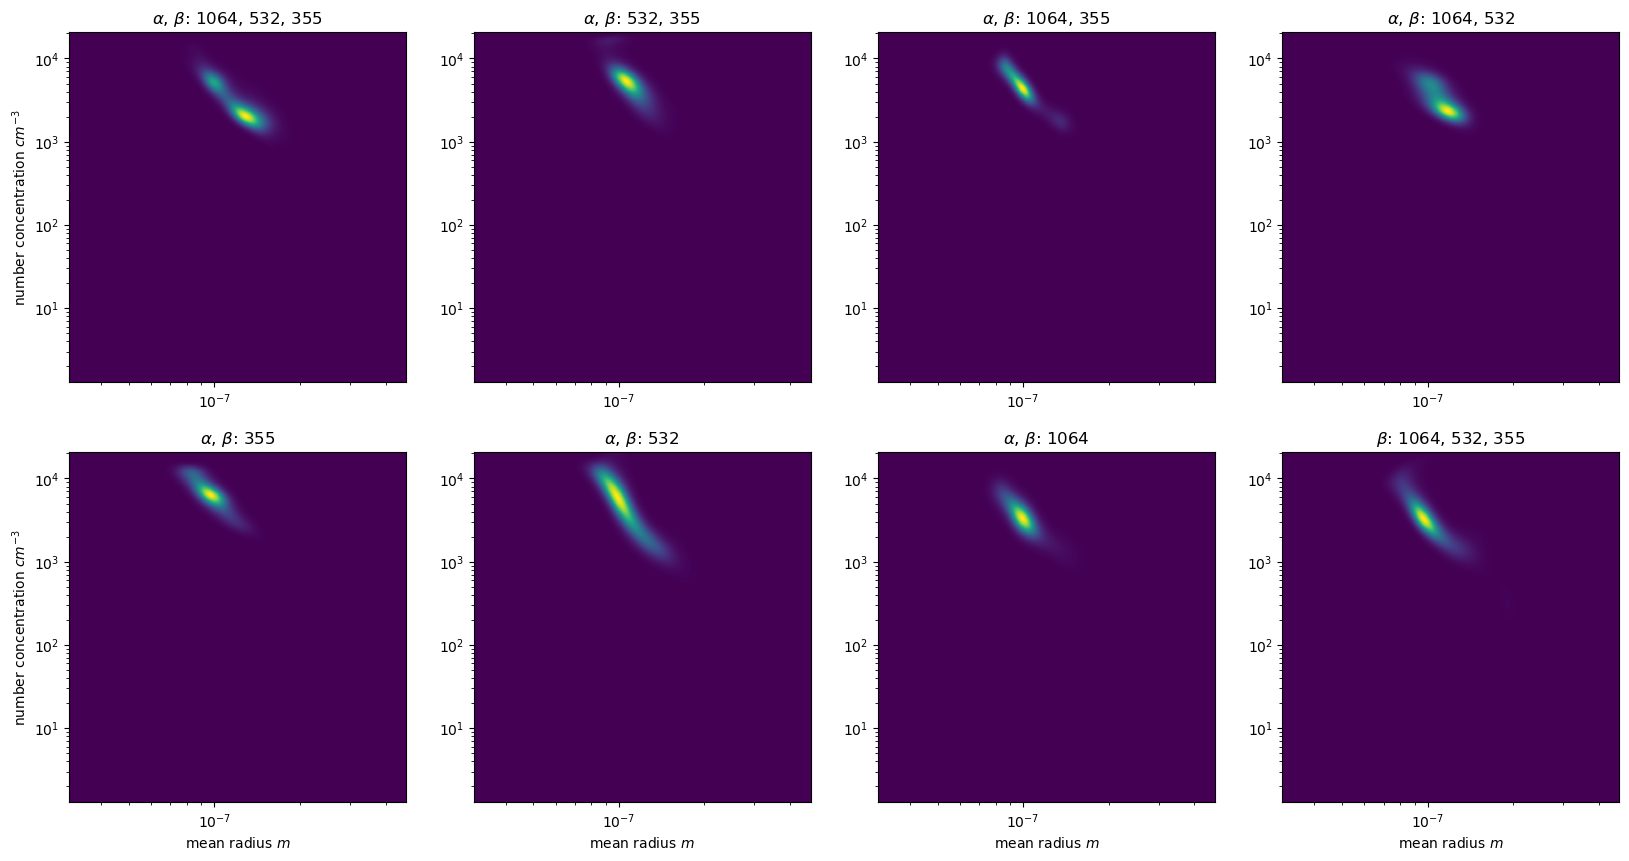

In [33]:
ex_idx = 4
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hn_2d in enumerate(hn_2d_lst):
    pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    f_pdf = f_pdf_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf)
    # ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf[0,...]/np.sum(f_pdf[0,...]))
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'mean radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

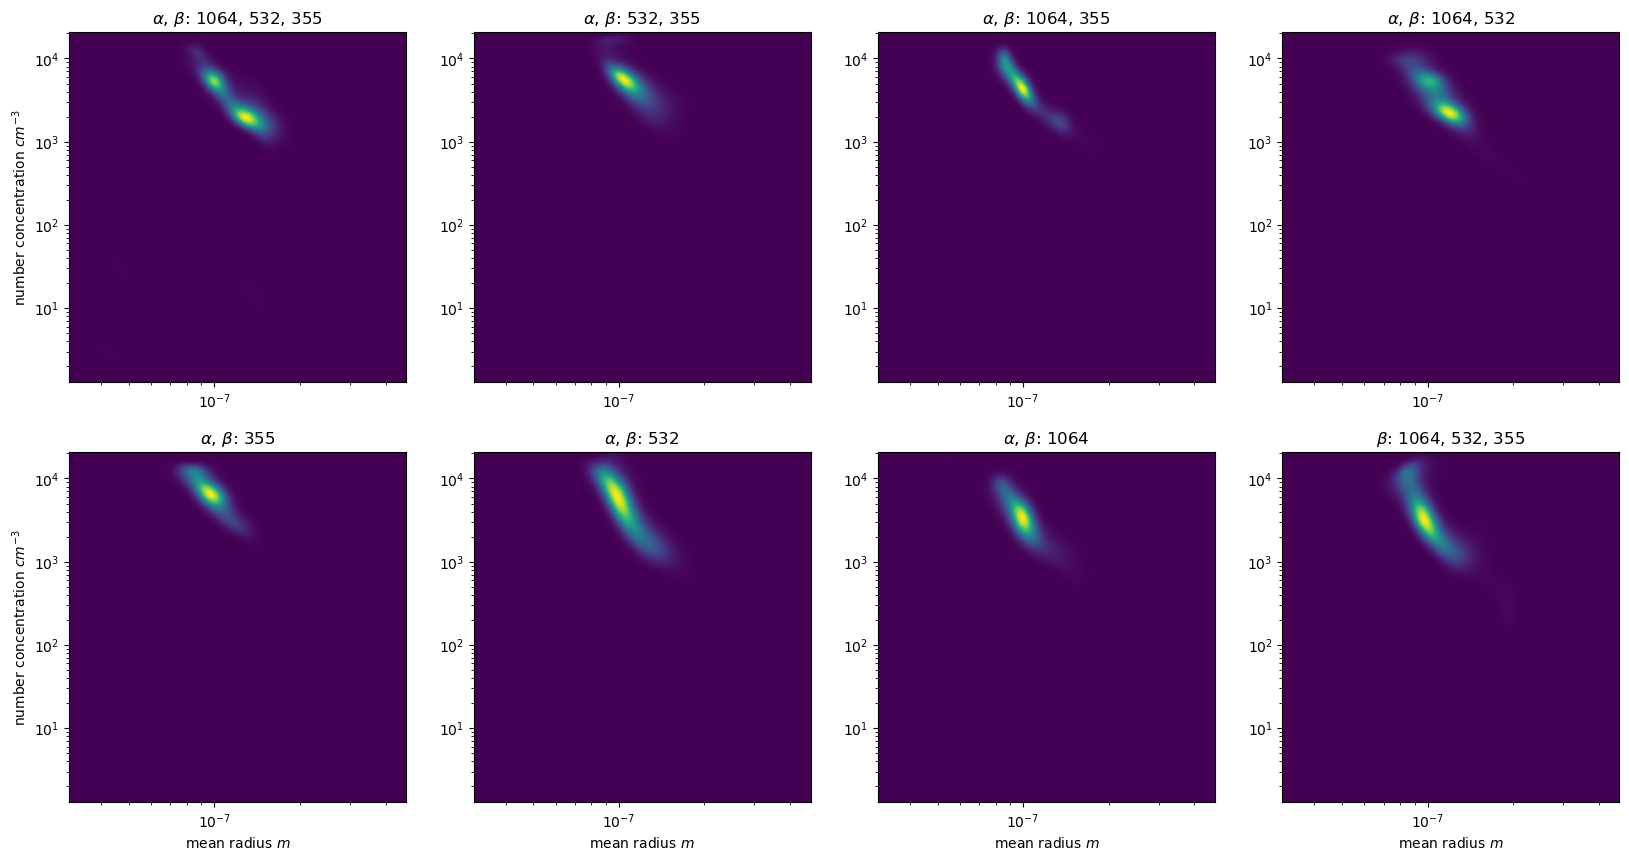

In [34]:
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hn_2d in enumerate(hn_2d_lst):
    pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    f_pdf = f_pdf_ens_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf)
    # ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf[0,...]/np.sum(f_pdf[0,...]))
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'mean radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

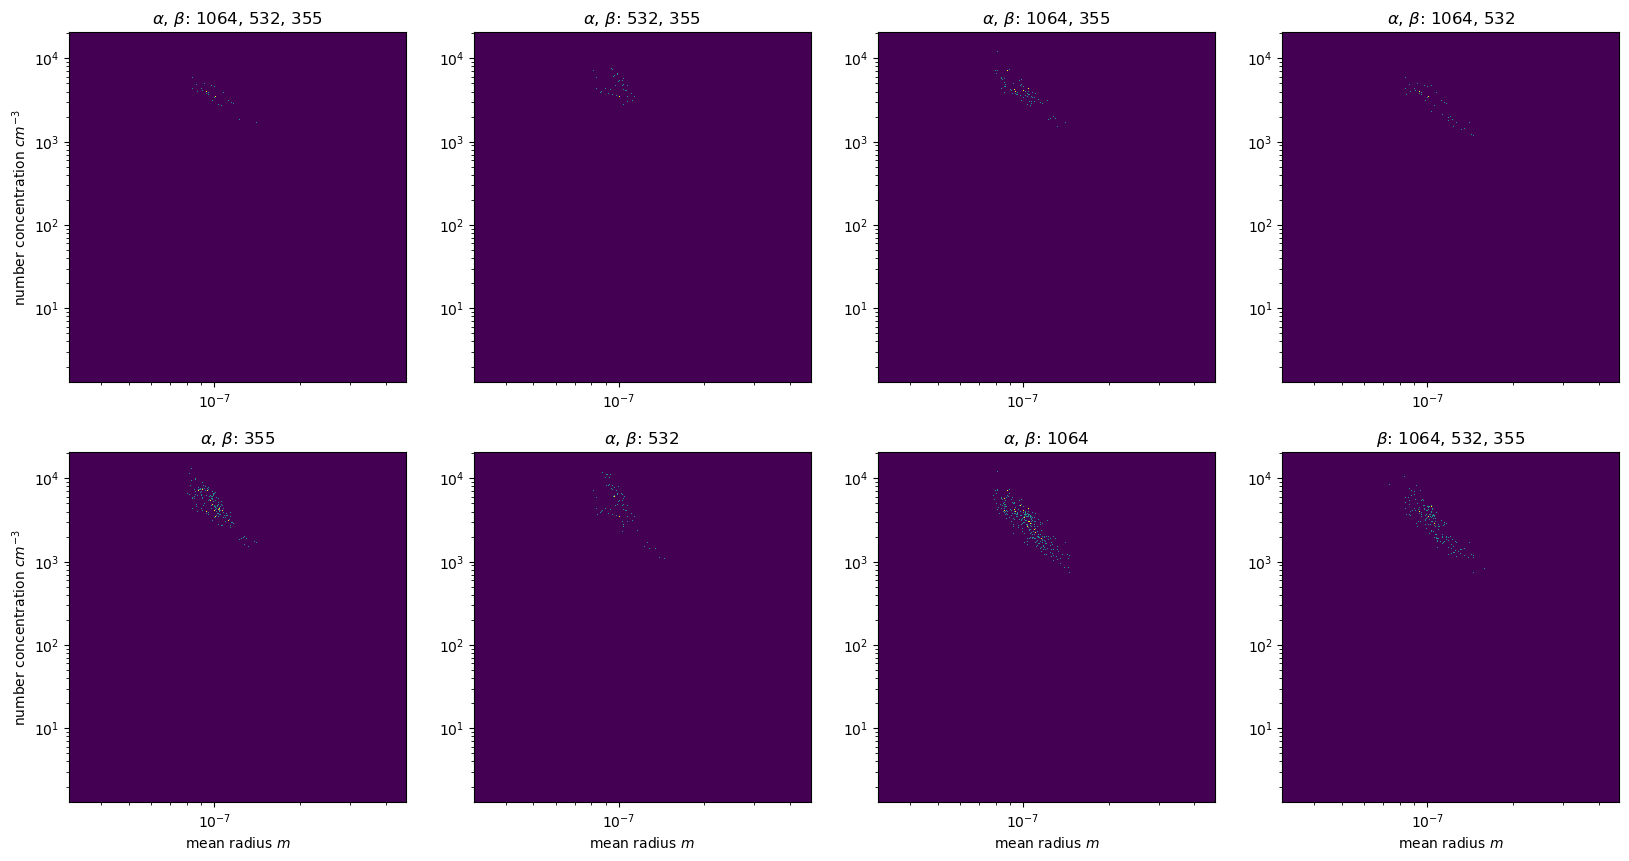

In [35]:
# ex_idx = 1
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, y_scaler in enumerate(y_rescale_lst):
    h_part = np.histogram2d(r_sim_hist_lst_lst[m_idx][ex_idx],n_sim_hist_lst_lst[m_idx][ex_idx],bins=np.linspace(0,1,500))
    hist_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([h_part[1],h_part[2]],axis=1)))
    # pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    # f_pdf = f_pdf_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(hist_ax[:,1],hist_ax[:,0],h_part[0].T/np.sum(h_part[0]))
    # ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf[0,...]/np.sum(f_pdf[0,...]))
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'mean radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

Text(0.5, 1.0, 'Prior and $\\alpha$, $\\beta$: 1064, 532, 355')

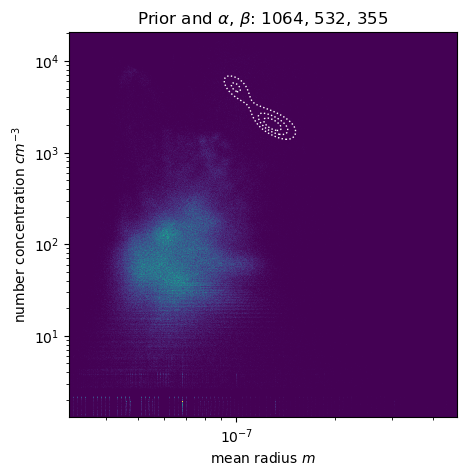

In [37]:
m_idx = 0  # model index
ex_idx = 4 # -1  # example index

hist_ax = np.exp(y_rescale_lst[-1].unscale(np.stack([0.5*(h_part_total[1][:-1]+h_part_total[1][1:]),
                                                0.5*(h_part_total[2][:-1]+h_part_total[2][1:])],axis=1)))
fig,ax = plt.subplots(1,1,figsize=(5,5))
# ax = ax_lst[m_idx]
f_pdf = f_pdf_arr_lst[m_idx][ex_idx,...]
ax.pcolormesh(hist_ax[:,1],hist_ax[:,0],h_part_total[0].T/np.sum(h_part_total[0]))
contours = ax.contour(pdf_ax[:,1],pdf_ax[:,0], f_pdf, levels = 3, colors='white', linestyles=':', linewidths=1)
ax.set_xscale('log')
ax.set_yscale('log')
# if m_idx//n_col == 1:
ax.set_xlabel(r'mean radius $m$')
# if m_idx%n_col == 0:
ax.set_ylabel(r'number concentration $cm^{-3}$')
# title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])

title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
ax.set_title("Prior and "+title)

In [55]:
in_data_unscale = x_scaler.unscale(in_data)
hist_in_data_unscale = x_scaler.unscale(hist_in_data)

plt.figure()
hbins = [np.logspace(-9,-4,100),np.logspace(-8,-3,200)]
total_hist = np.histogram2d(np.exp(hist_in_data_unscale[:,0:3]).flatten(),np.exp(hist_in_data_unscale[:,3:]).flatten(),bins=hbins)
# total_hist = np.histogram2d(np.exp(in_data_unscale[:,0:3]).flatten(),np.exp(in_data_unscale[:,3:]).flatten(),bins=hbins)
# plt.scatter(np.exp(in_data_unscale[:,0]),np.exp(in_data_unscale[:,3]),c='k',s=1,alpha=0.002)
# plt.scatter(np.exp(in_data_unscale[:,1]),np.exp(in_data_unscale[:,4]),c='k',s=1,alpha=0.002)
# plt.scatter(np.exp(in_data_unscale[:,2]),np.exp(in_data_unscale[:,5]),c='k',s=1,alpha=0.002)
plt.contour(hbins[0][1:], hbins[1][1:], total_hist[0].T, levels = 10, colors='k', linestyles='-', linewidths=1, alpha =0.3)

scatter_var1 = hist_in_data_unscale[:,0][sim_idx]
scatter_var2 = hist_in_data_unscale[:,3][sim_idx]
plt.scatter(np.exp(scatter_var1),np.exp(scatter_var2),c='tab:red',s=4,alpha=0.9)

scatter_var1 = hist_in_data_unscale[:,1][sim_idx]
scatter_var2 = hist_in_data_unscale[:,4][sim_idx]
plt.scatter(np.exp(scatter_var1),np.exp(scatter_var2),c='tab:green',s=4,alpha=0.9)

scatter_var1 = hist_in_data_unscale[:,2][sim_idx]
scatter_var2 = hist_in_data_unscale[:,5][sim_idx]
plt.scatter(np.exp(scatter_var1),np.exp(scatter_var2),c='tab:purple',s=4,alpha=0.9)

plt.xlabel('Backscatter Coefficient [$m^{-1} sr^{-1}$]')
plt.ylabel('Extinction Coefficient [$m^{-1}$]')
plt.xscale('log')
plt.yscale('log')

ValueError: x and y must have the same length.

<Figure size 640x480 with 0 Axes>

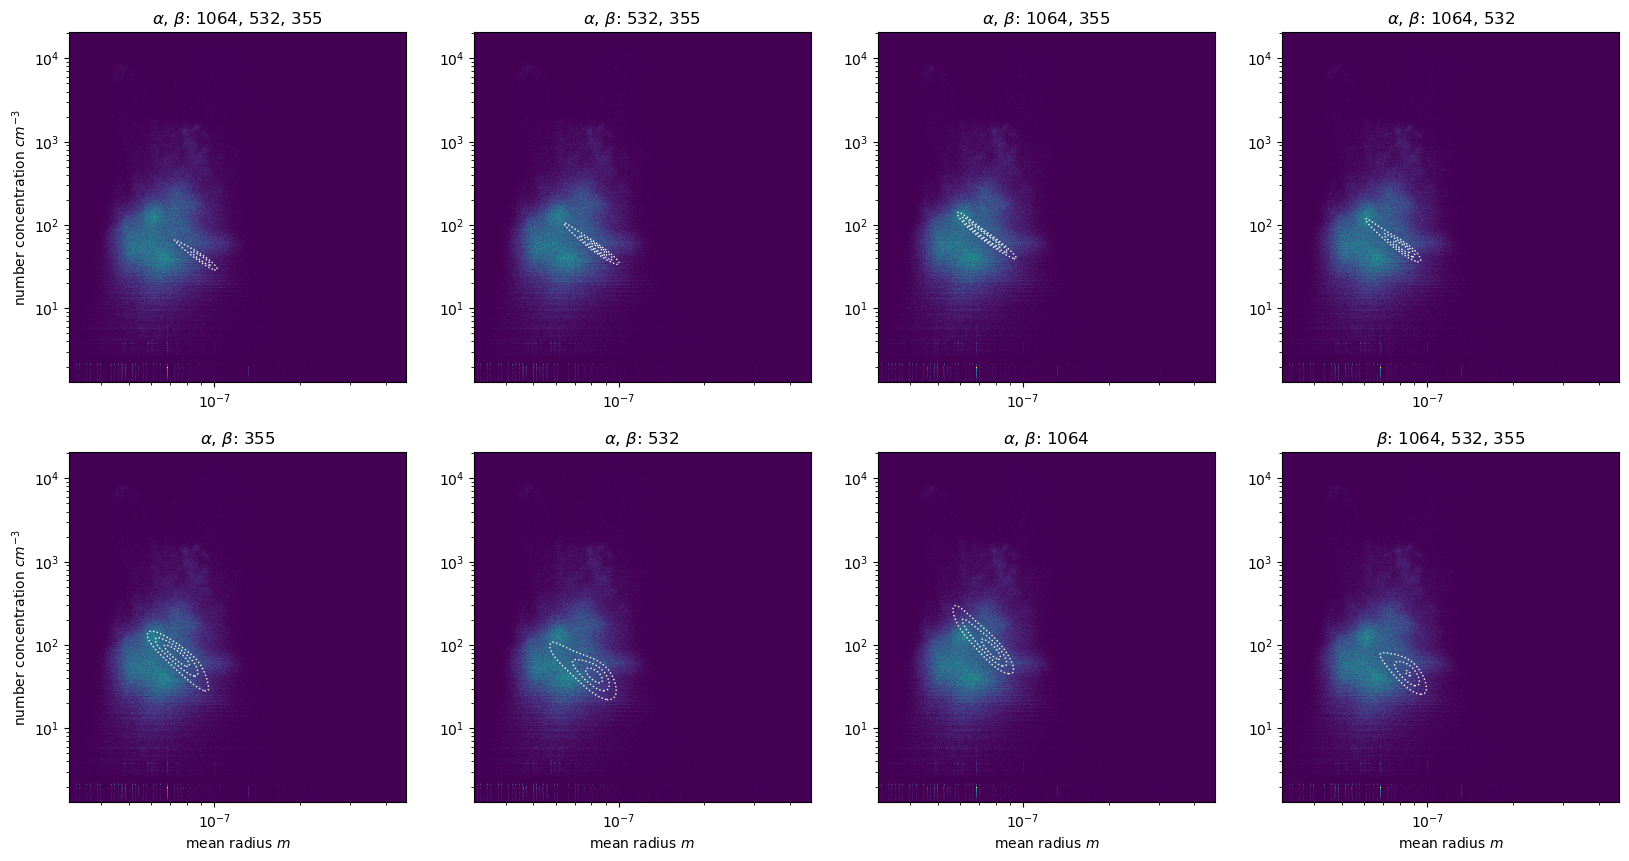

In [59]:
ex_idx = 0
n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hn_2d in enumerate(hn_2d_lst):
    pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    f_pdf = f_pdf_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(hist_ax[:,1],hist_ax[:,0],h_part_total[0].T/np.sum(h_part_total[0]))
    contours = ax.contour(pdf_ax[:,1],pdf_ax[:,0], f_pdf, levels = 3, colors='white', linestyles=':', linewidths=1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'mean radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

1-99 %


Text(0.5, 1.0, '$\\beta$: 1064, 532, 355')

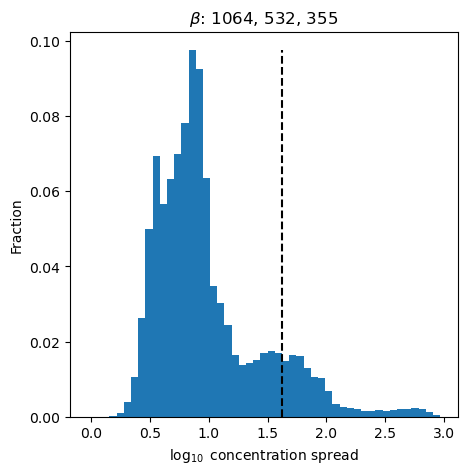

In [50]:
percentile_idx = 0
n_col = 1
n_row = 1 # int(np.ceil(len(hcmb_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
centroid_data_ln = centroid_data_ln_lst[m_idx]
act_data_ln = act_data_ln_lst[m_idx]
percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
percentile_delta = percentile_delta[:,0]
ax = ax_lst
hists = np.histogram(percentile_delta,
            bins=np.linspace(0,3,50))
ax.bar(hists[1][:-1],hists[0]/np.sum(hists[0]),width=np.diff(hists[1]))

ax.plot(2*[prior_percentile_delta[0,0]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

print(f"{(percentile_model_sets[m_idx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[m_idx][percentile_idx][1]*100):.0f} %")

ax.set_xlabel(r'$\log_{10}$ concentration spread')
ax.set_ylabel(r'Fraction')
title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
ax.set_title(title)


1-99 %


Text(0.5, 1.0, '$\\alpha$, $\\beta$: 1064, 532, 355')

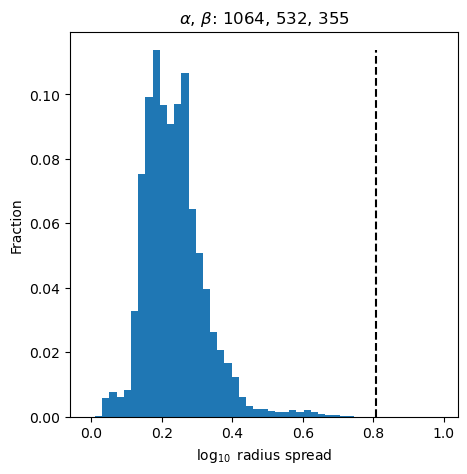

In [70]:
percentile_idx = 0
n_col = 1
n_row = 1 #int(np.ceil(len(hcmb_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
# ax_lst = ax_lst.ravel()

centroid_data_ln = centroid_data_ln_lst[m_idx]
act_data_ln = act_data_ln_lst[m_idx]
percentile_delta = (percentile_data_ln_lst_lst[m_idx][percentile_idx][1]-percentile_data_ln_lst_lst[m_idx][percentile_idx][0])*np.log10(np.exp(1))
percentile_delta = percentile_delta[:,1]
ax = ax_lst
hists = np.histogram(percentile_delta,
            bins=np.linspace(0,1,50))
ax.bar(hists[1][:-1],hists[0]/np.sum(hists[0]),width=np.diff(hists[1]))

ax.plot(2*[prior_percentile_delta[0,1]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

# ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
# x_ax_lim = ax.get_xlim()
# ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
#         [prior_percentile_delta[0,0]]*2,
#         'k--')
# ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
# ax.set_xscale('log')
# ax.set_yscale('log')

print(f"{(percentile_model_sets[m_idx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[m_idx][percentile_idx][1]*100):.0f} %")

ax.set_xlabel(r'$\log_{10}$ radius spread')
ax.set_ylabel(r'Fraction')
title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
ax.set_title(title)
# ax.set_xlim([-3,3])
# ax.set_ylim([0,3])

In [210]:
len(n_sim_hist_lst)

29

In [211]:
p1_interval = np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][0][idx_arr[ex_idx],1])
p2_interval = np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][1][idx_arr[ex_idx],1])

In [212]:
p1_interval

5.874588997931167e-08

In [213]:
p2_interval

1.0891552226947524e-07

In [214]:
p1_intervial_prior = percentile_prior_ln_lst[percentile_idx][1]
p2_intervial_prior = percentile_prior_ln_lst[percentile_idx][0]

In [215]:
p1_intervial_prior[0,1]

-15.294502076181159

Text(0, 0.5, 'Probability')

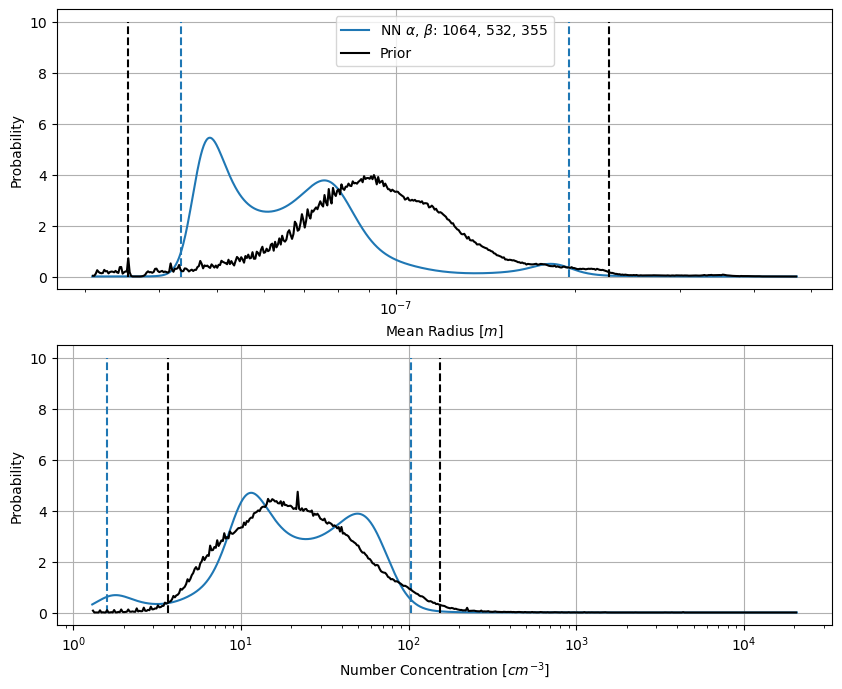

In [79]:
ex_idx = 10
plt_model_lst = [0,]
percentile_idx = 0

p1_interval_prior = percentile_prior_ln_lst[percentile_idx][0]
p2_interval_prior = percentile_prior_ln_lst[percentile_idx][1]

fig,ax = plt.subplots(2,1,figsize=(10,8))

for cnt, m_idx in enumerate(plt_model_lst):

    
    
    label = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])

    h_part = np.histogram2d(r_sim_hist_lst_lst[m_idx][ex_idx],n_sim_hist_lst_lst[m_idx][ex_idx],bins=np.linspace(0,1,500))
    
    hist_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([h_part[1],h_part[2]],axis=1)))
    pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    f_pdf = f_pdf_arr_lst[m_idx][ex_idx,...]
    f_pdf_ens = f_pdf_ens_arr_lst[m_idx][ex_idx,...]

    p1_interval = np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][0][idx_arr[ex_idx],1])
    p2_interval = np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][1][idx_arr[ex_idx],1])

    # ax[0].plot(hist_ax[1:,1],np.sum(h_part[0].T,axis=0)/np.sum(h_part[0])/np.mean(np.diff(h_part[1])),label='histogram '+label)
    ax[0].plot(pdf_ax[:,1],np.sum(f_pdf,axis=0)/np.sum(f_pdf)/np.mean(np.diff(x_plt)),'C%d-'%m_idx,label='NN '+label)
    # ax[0].plot(pdf_ax[:,1],np.sum(f_pdf_ens,axis=0)/np.sum(f_pdf_ens)/np.mean(np.diff(x_plt)),label='Ensemble NN')
    ax[0].plot([p1_interval,p1_interval],[0,10],'C%d--'%m_idx)
    ax[0].plot([p2_interval,p2_interval],[0,10],'C%d--'%m_idx)


    p1_interval = np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][0][idx_arr[ex_idx],0])
    p2_interval = np.exp(percentile_data_ln_lst_lst[m_idx][percentile_idx][1][idx_arr[ex_idx],0])

    # ax[1].plot(hist_ax[1:,0],np.sum(h_part[0].T,axis=1)/np.sum(h_part[0])/np.mean(np.diff(h_part[1])),label='histogram '+label)
    ax[1].plot(pdf_ax[:,0],np.sum(f_pdf,axis=1)/np.sum(f_pdf)/np.mean(np.diff(x_plt)),'C%d-'%m_idx,label='NN '+label)
    # ax[1].plot(pdf_ax[:,0],np.sum(f_pdf_ens,axis=1)/np.sum(f_pdf_ens)/np.mean(np.diff(x_plt)),label='Ensemble NN '+label)
    ax[1].plot([p1_interval,p1_interval],[0,10],'C%d--'%m_idx)
    ax[1].plot([p2_interval,p2_interval],[0,10],'C%d--'%m_idx)

    
# hist_ax = np.exp(y_rescale_lst[-1].unscale(np.stack([h_part_total[1],h_part_total[2]],axis=1)))
hist_ax = np.exp(y_rescale_lst[-1].unscale(np.stack([0.5*(h_part_total[1][:-1]+h_part_total[1][1:]),
                                                0.5*(h_part_total[2][:-1]+h_part_total[2][1:])],axis=1)))

ax[0].plot(hist_ax[:,1],np.sum(h_part_total[0],axis=0)/np.sum(h_part_total[0])/np.mean(np.diff(h_part_total[1])),label='Prior',color='k',linestyle='-')

ax[0].plot([np.exp(p1_interval_prior[0,1]),np.exp(p1_interval_prior[0,1])],[0,10],'k--')
ax[0].plot([np.exp(p2_interval_prior[0,1]),np.exp(p2_interval_prior[0,1])],[0,10],'k--')

ax[0].set_xscale('log')
ax[0].grid(visible=True)
ax[0].set_xlabel('Mean Radius [$m$]')
ax[0].set_ylabel('Probability')
ax[0].legend()

ax[1].plot(hist_ax[:,0],np.sum(h_part_total[0],axis=1)/np.sum(h_part_total[0])/np.mean(np.diff(h_part_total[1])),label='Prior',color='k',linestyle='-')
# ax[1].plot(hn_prior[1][:-1],h_part_total[0]/np.sum(hn_prior[0])),label="Prior",color='k',linestyle='--')

ax[1].plot([np.exp(p1_interval_prior[0,0]),np.exp(p1_interval_prior[0,0])],[0,10],'k--')
ax[1].plot([np.exp(p2_interval_prior[0,0]),np.exp(p2_interval_prior[0,0])],[0,10],'k--')

# ax[1].plot(hist_ax[1:,0],np.sum(h_part[0].T,axis=1)/np.sum(h_part[0])/np.mean(np.diff(h_part[1])),label='histogram')
# ax[1].plot(pdf_ax[:,0],np.sum(f_pdf[0,...],axis=1)/np.sum(f_pdf[0,...])/np.mean(np.diff(x_plt)),label='NN')
# ax[1].plot(pdf_ax[:,0],np.sum(f_pdf_ens,axis=1)/np.sum(f_pdf[0,...])/np.mean(np.diff(x_plt)),label='Ensemble NN')
ax[1].set_xscale('log')
ax[1].grid(visible=True)
ax[1].set_xlabel('Number Concentration [$cm^{-3}$]')
ax[1].set_ylabel('Probability')

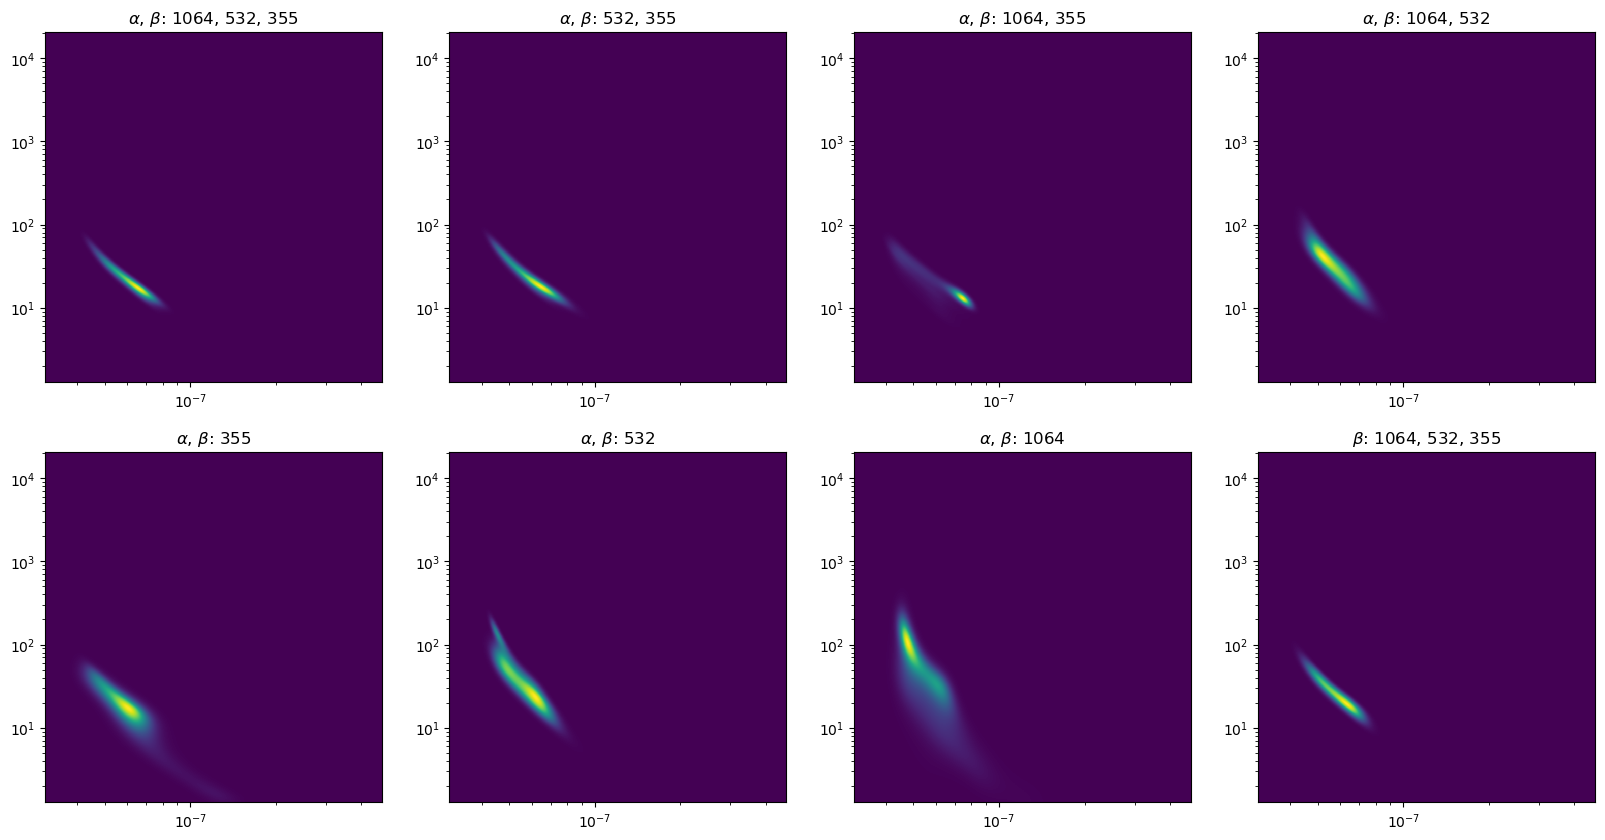

In [102]:
ex_idx = 2

n_col = 4
n_row = int(np.ceil(len(hcmb_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hn_2d in enumerate(hn_2d_lst):
    pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    f_pdf = f_pdf_ens_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf)
    ax.set_xscale('log')
    ax.set_yscale('log')
    # if m_idx//3 == 1:
    #     ax.set_xlabel(r'$\Delta log_{10}$ radius')
    # if m_idx%3 == 0:
    #     ax.set_ylabel(r'$\Delta log_{10}$ number concentration')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

In [ ]:
f_pdf.shape

In [52]:
f_pdf_ens_arr_lst[m_idx].shape

(4000, 1000)

In [ ]:
f_pdf_arr_lst

In [27]:
percentile_delta.shape

(90624, 2)

In [31]:
# interval_rescale
interval_data_ln = y_scaler.unscale(np.stack([n_interval_arr[:,0],r_interval_arr_lst[:,0]],axis=1))

TypeError: list indices must be integers or slices, not tuple

In [30]:
r_interval_arr = np.concatenate(r_interval_arr_lst,axis=0)
n_interval_arr = np.concatenate(n_interval_arr_lst,axis=0)

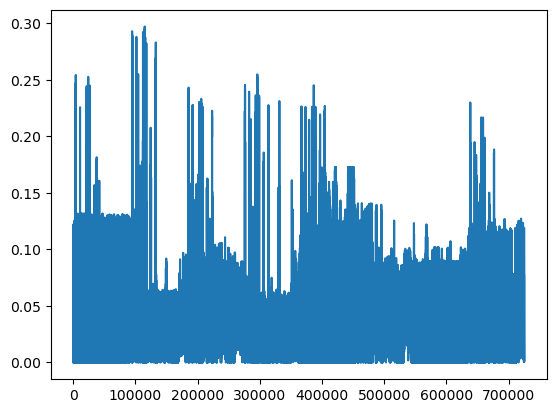

In [28]:
plt.figure()
plt.plot(r_interval_arr[:,-1] - r_interval_arr[:,0])

In [24]:
r_interval_lst[0].shape

(256, 6)

In [ ]:
np.exp(act_data_ln[:,1]),
                    np.exp(centroid_data_ln[:,1])

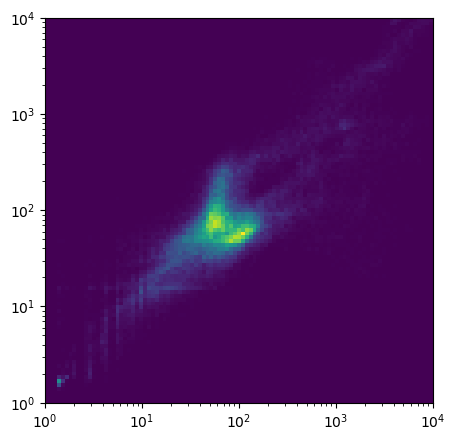

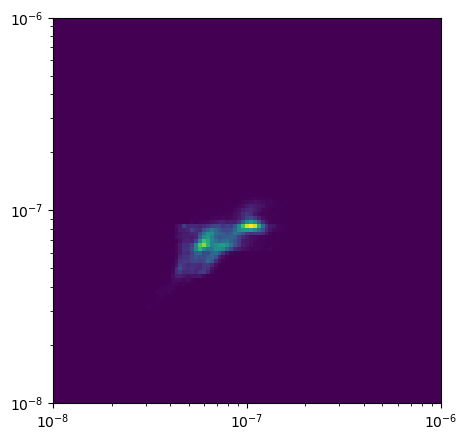

In [43]:
hn_2d = np.histogram2d(np.exp(act_data_ln[:,0]),
                    np.exp(centroid_data_ln[:,0]),
                    bins=(np.logspace(0,4,100),np.logspace(0,4,100)))

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.pcolormesh(hn_2d[1],hn_2d[2],hn_2d[0].T/np.sum(hn_2d[0]))
ax.set_xscale('log')
ax.set_yscale('log')


hr_2d = np.histogram2d(np.exp(act_data_ln[:,1]),
                    np.exp(centroid_data_ln[:,1]),
                    bins=(np.logspace(-8,-6,100),np.logspace(-8,-6,100)))

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.pcolormesh(hr_2d[1],hr_2d[2],hr_2d[0].T/np.sum(hr_2d[0]))
ax.set_xscale('log')
ax.set_yscale('log')

In [ ]:
# hr_ens = np.histogram(np.abs(act_data_ln[:,1]-centroid_ens_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(0,1,100))
plt.figure()
plt.plot(hr[1][:-1],hr[0])
# plt.plot(hr_ens[1][:-1],hr_ens[0])
plt.xlabel('$Log_{10}$ Radius difference')

# hn_ens = np.histogram(np.abs(act_data_ln[:,0]-centroid_ens_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(0,2,100))
plt.figure()
plt.plot(hn[1][:-1],hn[0])
# plt.plot(hn_ens[1][:-1],hn_ens[0])
plt.xlabel('$Log_{10}$ Number density difference')

In [34]:
10**0.3

1.9952623149688795

# Single Model Analysis

In [4]:
# model_str = "20250802T072914" # 3 wl, bs and ext, thinned by flight
# model_str = "20250802T201718" # 3 wl, bs, thinned by flight
model_str = "20250804T064411" # 2 wl, ext and bs, thinned by flight

conf_reload, model_reload = evid_nn.load_poly_nn_model(model_str,name_str='hyper_best',device=device)
x_scaler_r = evid_nn.rescale(0,1)
x_scaler_r.set_config(**conf_reload['save_model']['x_scaler'])
y_scaler_r = evid_nn.rescale(0,1)
y_scaler_r.set_config(**conf_reload['save_model']['y_scaler'])

loading model from 
/glade/u/home/mhayman/Python/aerosol-scattering/models


In [5]:
conf = conf_reload
dtype = model_reload.dtype

In [6]:
# model_config = "best_vld_flt1.yml"  # validation and test data are from flights randomly thinned from all HIPPO datasets

In [7]:
# config_file = os.path.join(os.environ['HOME'], 
#                     'Python',
#                     'aerosol-scattering',
#                     'config','echo',model_config)

# # config_file = os.path.join(os.environ['HOME'], 
# #                     'Python',
# #                     'aerosol-scattering','scripts','casper',
# #                     'echo_config','polynn_model_config.yml')

# with open(config_file) as cf:
#     conf = yaml.load(cf, Loader=yaml.FullLoader)

In [8]:
def transpose_and_flatten_data_array(da: xr.DataArray,flattened_dim_name:str = None) -> xr.DataArray:
    """
    Transposes an xarray DataArray so the first dimension is 'data_index'
    and all other dimensions are flattened into a single second dimension
    named 'flattened_dims'.

    Args:
        da (xr.DataArray): The input DataArray.

    Returns:
        xr.DataArray: The reshaped DataArray with dimensions ('data_index', 'flattened_dims').
                      The 'flattened_dims' dimension will have a MultiIndex if multiple
                      dimensions were stacked, preserving original coordinate information.
    """

    # --- Handle Scalar DataArray ---
    # If the DataArray is a scalar (no dimensions), expand it to a (1,1) array
    # with the desired dimension names.
    if not da.dims:
        return da.expand_dims({'data_index': 1, 'flattened_dims': 1})

    # --- Prepare Dimensions ---
    original_dims = list(da.dims)
    data_index_dim_name = 'data_index'
    if flattened_dim_name is None:
        flattened_dim_name = 'input_vars'

    # Step 1: Ensure 'data_index' is a dimension and is the first dimension.
    if data_index_dim_name not in original_dims:
        # If 'data_index' is not present, assume the current first dimension
        # should be renamed to 'data_index'.
        first_dim_original_name = original_dims[0]
        da = da.rename({first_dim_original_name: data_index_dim_name})
        # Update the list of original_dims to reflect the rename
        original_dims = list(da.dims)
    
    # Now, 'data_index' is guaranteed to be a dimension in `da`.
    # Ensure 'data_index' is the very first dimension.
    if da.dims[0] != data_index_dim_name:
        # Use .transpose() to move 'data_index' to the first position,
        # keeping the relative order of other dimensions.
        da = da.transpose(data_index_dim_name, *[d for d in da.dims if d != data_index_dim_name])

    # --- Flatten Other Dimensions ---
    # Identify all dimensions that are NOT 'data_index'. These will be flattened.
    dims_to_flatten = [d for d in da.dims if d != data_index_dim_name]

    if not dims_to_flatten:
        # If there are no other dimensions (e.g., the original array was already
        # just ('data_index',)), we need to add a 'flattened_dims' dimension
        # of size 1 to achieve the target 2D structure.
        # We use axis=1 to add it as the second dimension.
        return da.expand_dims(flattened_dim_name, axis=1)

    # Use .stack() to combine the identified dimensions into a single new dimension.
    # xarray's .stack() method automatically creates a MultiIndex for the new dimension,
    # which is excellent for preserving the original coordinate information.
    # The new stacked dimension will be added as the last dimension by default.
    # Since 'data_index' was already moved to the first position, the final order
    # will be (data_index, flattened_dims), which is the desired outcome.
    stacked_da = da.stack({flattened_dim_name: dims_to_flatten})

    return stacked_da

In [9]:
os.path.join(conf['data']['valid_data_path'],conf['data']['valid_data_file'])

'/glade/derecho/scratch/mhayman/aerosol/datasets/hippo_aerosol_training_data_valid.nc'

In [10]:
override_validation = False  # forces the validation data to be split from training

rank = 0
trial = False


device = torch.device(f"cuda:{rank % torch.cuda.device_count()}") if torch.cuda.is_available() else torch.device("cpu")
torch.cuda.set_device(rank % torch.cuda.device_count())
if conf['model']['dtype'] == 'float32':
    dtype = torch.float32
elif conf['model']['dtype'] == 'float64':
    dtype = torch.float64
else:
    dtype = torch.float

# Config settings
# seed = 1000 if "seed" not in conf else conf["seed"]
# seed_everything(seed)


# train_ds = xr.open_dataset(os.path.join(conf['data']['data_path'],conf['data']['data_file']))
ds = xr.open_dataset(os.path.join(conf['data']['data_path'],conf['data']['data_file']))

train_batch_size = conf['data']['batch_size']
valid_batch_size = conf['data']['batch_size']
test_batch_size = conf['data']['batch_size']

train_idx = int(np.round(ds.sizes['data_index']*conf['data']['train_fraction']))
valid_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['valid_fraction']))
test_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['test_fraction']))

# ds = train_ds

input_lst = []
input_str_lst = []
for var in conf['data']['wavelength_inputs']:
    for wl in conf['data']['wavelength_inputs'][var]['wavelength_lst']:
        input_lst.append(transpose_and_flatten_data_array(ds[var].sel(wavelength=wl)))
        input_str_lst.append(var+f"_{int(wl*1e9)}")
for var in conf['data']['input_cols']:
    input_lst.append(transpose_and_flatten_data_array(ds[var],flattened_dim_name='input_vars'))
    input_str_lst.append(var)

# train_input_arr = xr.concat(input_lst,'input_vars')
train_input_arr = xr.concat(input_lst,pd.Index(input_str_lst,name='input_vars'))

output_lst = []
output_str_lst = []
for var in conf['data']['output_cols']:
    output_lst.append(transpose_and_flatten_data_array(ds[var],flattened_dim_name='label_vars'))
    output_str_lst.append(var)

train_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))

# x_scaler = evid_nn.rescale(0,1,axes=(0,))
# y_scaler = evid_nn.rescale(0,1,axes=(0,))

# x_scaler.set_scale(np.log(train_input_arr.values))
# y_scaler.set_scale(np.log(train_label_arr.values))

# try:
if not override_validation:
    valid_ds = xr.open_dataset(os.path.join(conf['data']['valid_data_path'],conf['data']['valid_data_file']))
    input_lst = []
    # input_str_lst = []
    for var in conf['data']['wavelength_inputs']:
        for wl in conf['data']['wavelength_inputs'][var]['wavelength_lst']:
            input_lst.append(transpose_and_flatten_data_array(valid_ds[var].sel(wavelength=wl)))
            # input_str_lst.append(var+f"_{int(wl*1e9)}")
    for var in conf['data']['input_cols']:
        input_lst.append(transpose_and_flatten_data_array(valid_ds[var],flattened_dim_name='input_vars'))
        # input_str_lst.append(var)
    
    # train_input_arr = xr.concat(input_lst,'input_vars')
    valid_input_arr = xr.concat(input_lst,pd.Index(input_str_lst,name='input_vars'))
    
    output_lst = []
    # output_str_lst = []
    for var in conf['data']['output_cols']:
        output_lst.append(transpose_and_flatten_data_array(valid_ds[var],flattened_dim_name='label_vars'))
        # output_str_lst.append(var)
    
    valid_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))
    
    x_train = x_scaler.scale(np.log(train_input_arr.values))
    x_valid = x_scaler.scale(np.log(valid_input_arr.values))
    
    y_train = y_scaler.scale(np.log(train_label_arr.values))
    y_valid = y_scaler.scale(np.log(valid_label_arr.values))
# except Exception as E:
else:
    print("validation dataset encountered an error:")
    print("override_validation=True, so validation is split from training data")
    # print(str(E))
    x_train = x_scaler.scale(np.log(train_input_arr.values[:train_idx,:]))
    x_valid = x_scaler.scale(np.log(train_input_arr.values[train_idx:valid_idx,:]))
    
    y_train = y_scaler.scale(np.log(train_label_arr.values[:train_idx,:]))
    y_valid = y_scaler.scale(np.log(train_label_arr.values[train_idx:valid_idx,:]))
    
# x_train = x_scaler.scale(np.log(train_input_arr.values[:train_idx,:]))
# x_valid = x_scaler.scale(np.log(train_input_arr.values[train_idx:valid_idx,:]))
# x_test = x_scaler.scale(np.log(train_input_arr.values[valid_idx:,:]))


# y_train = y_scaler.scale(np.log(train_label_arr.values[:train_idx,:]))
# y_valid = y_scaler.scale(np.log(train_label_arr.values[train_idx:valid_idx,:]))
# y_test = y_scaler.scale(np.log(train_label_arr.values[valid_idx:,:]))

# cond_args = {
#     'in_norm_arr':1,
#     'in_bias_arr':0,
#     'out_norm_arr':1,
#     'out_bias_arr':0,
# }

cond_args = conf['data']['cond_args']

train_dataset = evid_nn.EvidDataset(x_train,y_train,
                            dtype=dtype,device=device,
                            **cond_args)
valid_dataset = evid_nn.EvidDataset(x_valid,y_valid,
                            dtype=dtype,device=device,
                            **cond_args)
# test_dataset = evid_nn.EvidDataset(x_test,y_test,
#                             dtype=dtype,device=device,
#                             **cond_args)

train_dataloader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=valid_batch_size, shuffle=True)
# test_dataloader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

In [11]:
test_ds = xr.open_dataset(os.path.join(conf['data']['test_data_path'],conf['data']['test_data_file']))
input_lst = []
# input_str_lst = []
for var in conf['data']['wavelength_inputs']:
    for wl in conf['data']['wavelength_inputs'][var]['wavelength_lst']:
        input_lst.append(transpose_and_flatten_data_array(test_ds[var].sel(wavelength=wl)))
for var in conf['data']['input_cols']:
    input_lst.append(transpose_and_flatten_data_array(test_ds[var],flattened_dim_name='input_vars'))

test_input_arr = xr.concat(input_lst,pd.Index(input_str_lst,name='input_vars'))

output_lst = []
for var in conf['data']['output_cols']:
    output_lst.append(transpose_and_flatten_data_array(test_ds[var],flattened_dim_name='label_vars'))

test_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))

x_test = x_scaler.scale(np.log(test_input_arr.values))

y_test = y_scaler.scale(np.log(test_label_arr.values))

test_dataset = evid_nn.EvidDataset(x_test,y_test,
                            dtype=dtype,device=device,
                            **cond_args)

test_dataloader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

In [12]:
# in_data = x_train
# out_label = y_train

# in_data = x_valid
# out_label = y_valid

in_data = x_test
out_label = y_test

hist_width = 0.01

# # TODO this should only sample from test data, but the histogram data should use all the data
# # idx = 1834
# # idx = 131398
# # idx = 974538
# # idx = 49570 # bimodal
# # idx = 886401
# # idx = 714798
# # idx= 0
# idx = int(np.random.rand()*in_data.shape[0])  # get random input


# print(f"index: {idx}")

# hist_in_data = x_train
# hist_out_label = y_train

# # get histogram data.  This should sample from all of the data (not just test data)
# sim_idx = np.where(np.prod(np.abs(hist_in_data - in_data[idx,:].reshape(1,-1)) < hist_width,axis=1))
# # r_sim = out_label[:,1][sim_idx]
# # n_sim = out_label[:,0][sim_idx]

# r_sim_hist = hist_out_label[:,1][sim_idx]
# n_sim_hist = hist_out_label[:,0][sim_idx]

# r_act = out_label[:,1][idx]
# n_act = out_label[:,0][idx]

In [13]:
# model_str = "20250802T072914" # 3 wl, bs and ext, thinned by flight
# model_str = "20250802T201718" # 3 wl, bs, thinned by flight

# conf_reload, model_reload = evid_nn.load_poly_nn_model("20250802T072914",name_str='hyper_best',dtype=dtype,device=device)
# x_scaler_r = evid_nn.rescale(0,1)
# x_scaler_r.set_config(**conf_reload['save_model']['x_scaler'])
# y_scaler_r = evid_nn.rescale(0,1)
# y_scaler_r.set_config(**conf_reload['save_model']['y_scaler'])

In [14]:
in_data.shape

(90683, 4)

In [15]:
batch_size = 64
ensemble_size = 100
ensemble_width = 0.01 # (observation uncertainty)
batch_count = in_data.shape[0]//batch_size

r_centroid_lst = []
n_centroid_lst = []
r2_centroid_lst = []
n2_centroid_lst = []
r_centroid_ens_lst = []
n_centroid_ens_lst = []
r_act_lst = []
n_act_lst = []
p_model_lst = []

for batch in tqdm.tqdm(range(batch_count)):
    input_batch = torch.tensor(in_data[batch*batch_size:((batch+1)*batch_size),:], dtype=dtype, device=device)
    
    f_pdf_tnsr = model_reload.output_pdf(input_batch)
    f_pdf = f_pdf_tnsr.detach().cpu().numpy()
    x_plt = model_reload.x_int.detach().cpu().numpy()
    dx2 = (model_reload.dx_int**2).detach().cpu().numpy()

    r_centroid_lst.append(torch.sum(model_reload.x_int.detach().reshape(1,1,-1)*f_pdf_tnsr*model_reload.dx_int**2,dim=(1,2)).detach().cpu().numpy())
    n_centroid_lst.append(torch.sum(model_reload.x_int.detach().reshape(1,-1,1)*f_pdf_tnsr*model_reload.dx_int**2,dim=(1,2)).detach().cpu().numpy())
    r2_centroid_lst.append(torch.sum(model_reload.x_int.detach().reshape(1,1,-1)**2*f_pdf_tnsr*model_reload.dx_int**2,dim=(1,2)).detach().cpu().numpy())
    n2_centroid_lst.append(torch.sum(model_reload.x_int.detach().reshape(1,-1,1)**2*f_pdf_tnsr*model_reload.dx_int**2,dim=(1,2)).detach().cpu().numpy())

    r_act_lst.append(out_label[batch*batch_size:((batch+1)*batch_size),1])
    n_act_lst.append(out_label[batch*batch_size:((batch+1)*batch_size),0])

    fit_coef = model_reload.net(input_batch)
    p_model = model_reload.fpdf(fit_coef, input_batch)
    p_model_lst.append(p_model.detach().cpu().numpy())
    
    # ensemble_size = 1
    # ensemble_width = hist_width # (observation uncertainty)
    # loop_length = 10
    # f_pdf_ens_tnsr = torch.zeros(f_pdf.shape,dtype=dtype,device=device) # np.zeros(f_pdf.shape)
    # # f_pdf_ens = np.zeros((f_pdf.shape[1],f_pdf.shape[2]))
    # for ens_group_idx in range(loop_length):
    #     input_batch_ens = (input_batch[:,None,:] + (torch.rand(batch_size,ensemble_size,in_data.shape[1],dtype=dtype,device=device)*2-1)*ensemble_width).reshape(-1,in_data.shape[1])
    #     f_pdf_ens_tnsr0 = model_reload.output_pdf(input_batch_ens)
    #     f_pdf_ens_tnsr += torch.sum(f_pdf_ens_tnsr0.reshape(batch_size,ensemble_size,f_pdf_tnsr.shape[1],f_pdf_tnsr.shape[2]),axis=1)
    #     # f_pdf_ens += f_pdf_ens_tnsr.detach().cpu().numpy()
    #     # f_pdf_ens += np.sum(f_pdf_ens_tnsr.detach().cpu().numpy(),axis=0)
    #     # print(ens_group_idx)
    
    # f_pdf_ens = f_pdf_ens_tnsr.detach().cpu().numpy()/(loop_length*ensemble_size)

    # r_centroid_ens_lst.append(np.sum(np.sum(x_plt.reshape(1,1,-1)*f_pdf_ens*dx2,axis=2),axis=1))
    # n_centroid_ens_lst.append(np.sum(np.sum(x_plt.reshape(1,-1,1)*f_pdf_ens*dx2,axis=2),axis=1))

100%|██████████| 1416/1416 [04:59<00:00,  4.74it/s]


In [17]:
f_pdf_ens_tnsr.shape

torch.Size([256, 1000, 1000])

In [28]:
f_pdf_tnsr.shape

torch.Size([256, 1000, 1000])

In [30]:
f_pdf_ens_tnsr.shape

torch.Size([512, 1000, 1000])

In [31]:
f_pdf.shape

(256, 1000, 1000)

In [18]:
(torch.rand(batch_size,in_data.shape[1],ensemble_size)*2-1)*ensemble_width

tensor([[[ 0.0048, -0.0075, -0.0076,  ..., -0.0002,  0.0023,  0.0024],
         [ 0.0071, -0.0044, -0.0040,  ..., -0.0012,  0.0079,  0.0034],
         [-0.0018,  0.0040,  0.0007,  ...,  0.0041, -0.0007, -0.0006]],

        [[ 0.0026, -0.0017,  0.0092,  ...,  0.0005,  0.0011, -0.0097],
         [ 0.0089,  0.0030, -0.0051,  ...,  0.0049,  0.0066,  0.0071],
         [ 0.0032, -0.0053,  0.0078,  ..., -0.0082, -0.0041, -0.0015]],

        [[-0.0068,  0.0057, -0.0061,  ...,  0.0089,  0.0072, -0.0043],
         [-0.0075,  0.0085,  0.0093,  ..., -0.0052, -0.0093, -0.0054],
         [-0.0091, -0.0012, -0.0048,  ...,  0.0055,  0.0054,  0.0016]],

        ...,

        [[ 0.0082, -0.0097, -0.0073,  ..., -0.0072,  0.0056,  0.0011],
         [ 0.0059, -0.0032, -0.0017,  ...,  0.0015,  0.0025, -0.0074],
         [-0.0029, -0.0031,  0.0049,  ..., -0.0043, -0.0031,  0.0081]],

        [[ 0.0030, -0.0085, -0.0040,  ..., -0.0004,  0.0094,  0.0006],
         [-0.0078, -0.0026, -0.0050,  ...,  0.0042, -0.

In [16]:
np.sum(np.sum(f_pdf_ens,axis=2),axis=1)*dx2

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [15]:
dx2 = (model_reload.dx_int**2).detach().cpu().numpy()

In [16]:
f_pdf_tnsr.shape

torch.Size([256, 1000, 1000])

In [27]:
f_pdf_ens_tnsr.shape

torch.Size([512, 1000, 1000])

In [17]:
f_pdf_ens.shape

(256, 1000, 1000)

In [18]:
model_reload.x_int.detach().shape

torch.Size([1000])

In [19]:
batch

353

In [20]:
input_batch.shape

torch.Size([256, 6])

In [21]:
np.concatenate(r_centroid_ens_lst).shape

(90624,)

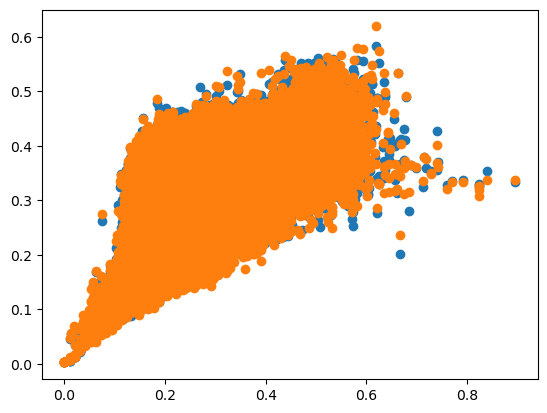

In [34]:
plt.figure()
plt.scatter(np.concatenate(r_act_lst),np.concatenate(r_centroid_lst))
plt.scatter(np.concatenate(r_act_lst),np.concatenate(r_centroid_ens_lst))

Text(0.5, 0, '$Log_{10}$ Number density difference')

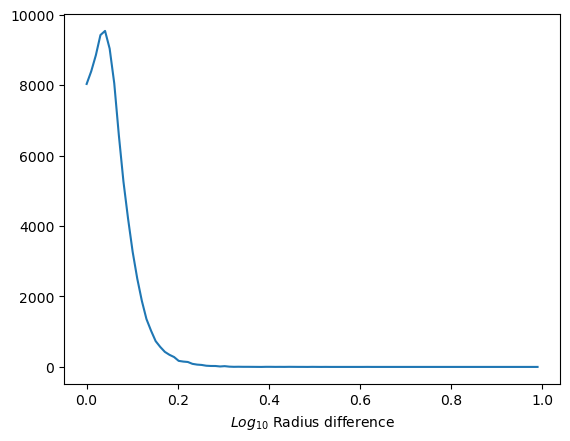

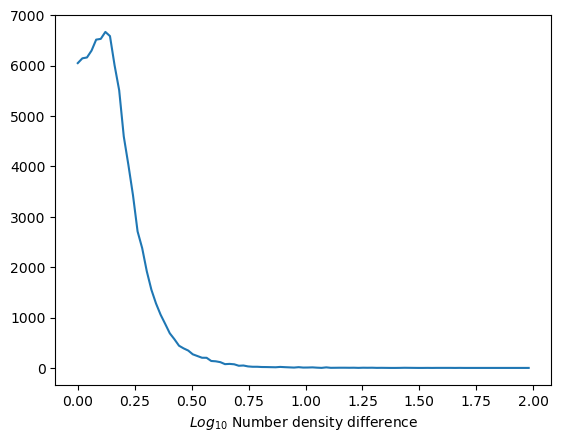

In [17]:
act_data_ln = y_scaler.unscale(np.stack([np.concatenate(n_act_lst),np.concatenate(r_act_lst)],axis=1))
centroid_data_ln = y_scaler.unscale(np.stack([np.concatenate(n_centroid_lst),np.concatenate(r_centroid_lst)],axis=1))
# centroid_ens_data_ln = y_scaler.unscale(np.stack([np.concatenate(n_centroid_ens_lst),np.concatenate(r_centroid_ens_lst)],axis=1))

hr = np.histogram(np.abs(act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(0,1,100))
# hr_ens = np.histogram(np.abs(act_data_ln[:,1]-centroid_ens_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(0,1,100))
plt.figure()
plt.plot(hr[1][:-1],hr[0])
# plt.plot(hr_ens[1][:-1],hr_ens[0])
plt.xlabel('$Log_{10}$ Radius difference')

hn = np.histogram(np.abs(act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(0,2,100))
# hn_ens = np.histogram(np.abs(act_data_ln[:,0]-centroid_ens_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(0,2,100))
plt.figure()
plt.plot(hn[1][:-1],hn[0])
# plt.plot(hn_ens[1][:-1],hn_ens[0])
plt.xlabel('$Log_{10}$ Number density difference')

Text(0.5, 1.0, 'Deviation from Centroid')

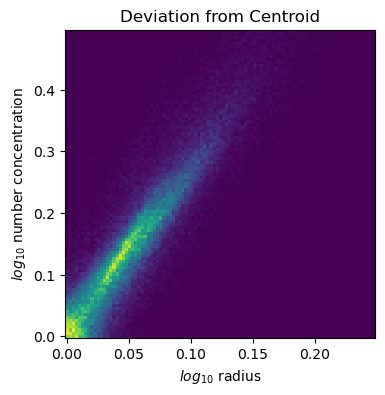

In [18]:
hcmb = np.histogram2d(np.abs(act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),
                    np.abs(act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),
                    bins=(np.linspace(0,0.25,100),np.linspace(0,0.5,100)))

# hcmb_ens = np.histogram2d(np.abs(act_data_ln[:,1]-centroid_ens_data_ln[:,1])*np.log10(np.exp(1)),
#                     np.abs(act_data_ln[:,0]-centroid_ens_data_ln[:,0])*np.log10(np.exp(1)),
#                     bins=(np.linspace(0,0.25,100),np.linspace(0,0.5,100)))

fig,ax = plt.subplots(1,1,figsize=(4,4))

ax.pcolormesh(hcmb[1][:-1],hcmb[2][:-1],hcmb[0].T/np.sum(hcmb[0]))

xl = ax.get_xlim()
yl = ax.get_ylim()
# contours = ax[0].contour(pdf_ax[:,1],pdf_ax[:,0], f_pdf[0,...], levels = 1, colors='white', linestyles=':', linewidths=1)
# ax.scatter(act_ax[1],act_ax[0],c='tab:red',marker='x',)
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlim(xl)
# ax.set_ylim(yl)
ax.set_xlabel(r'$log_{10}$ radius')
ax.set_ylabel(r'$log_{10}$ number concentration')
ax.set_title('Deviation from Centroid')

# fig,ax = plt.subplots(1,1,figsize=(4,4))

# ax.pcolormesh(hcmb_ens[1][:-1],hcmb_ens[2][:-1],hcmb_ens[0].T/np.sum(hcmb_ens[0]))

# xl = ax.get_xlim()
# yl = ax.get_ylim()
# # contours = ax[0].contour(pdf_ax[:,1],pdf_ax[:,0], f_pdf[0,...], levels = 1, colors='white', linestyles=':', linewidths=1)
# # ax.scatter(act_ax[1],act_ax[0],c='tab:red',marker='x',)
# # ax.set_xscale('log')
# # ax.set_yscale('log')
# # ax.set_xlim(xl)
# # ax.set_ylim(yl)
# ax.set_xlabel(r'$log_{10}$ radius')
# ax.set_ylabel(r'$log_{10}$ number concentration')
# ax.set_title('Deviation from Centroid (Ensemble)')

In [99]:
(act_data_ln[:,0]-centroid_data_ln[:,0])

array([ 1.18966267, -0.0618497 , -0.26183775, ...,  0.94528501,
        0.65844917,  0.65663844])

In [20]:
h_interp = np.interp(r_data, hr[1][:-1], hr[0]/np.sum(hr[0]))
plt.figure()
plt.scatter(h_interp,np.concatenate(p_model_lst)*dx2)
# plt.xlim([0,0.1])
plt.ylim([0,1e-9])
# plt.yscale('log')

NameError: name 'r_data' is not defined

In [50]:
torch.sum(f_pdf_tnsr,dim=(1,2))*model_reload.dx_int**2

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 

In [48]:
f_pdf_tnsr*model_reload.dx_int

TypeError: only integer tensors of a single element can be converted to an index

In [47]:
model_reload.dx_int

tensor(0.0010, device='cuda:0', dtype=torch.float64)